# 🚀 SAIR PyTorch Mastery - Lecture 8A: The HuggingFace Ecosystem
## From Scratch to Production: The Modern NLP Engine

**Course:** Applied Deep Learning with PyTorch  
**Module:** Sequence & NLP  
**Instructor:** Mohammed Awad Ahmed (Silva)  
**SAIR Community:** Building Sudan's AI Future 🇸🇩

---

## 📘 Welcome to the Modern NLP Engine!

In Lectures 5 and 6, you did something most people never do — you **built everything from scratch**.
You wrote the vocabulary builder, the training loop, the sampling strategies, the beam search.
You felt the pain of 300 lines of code to get 87% accuracy on IMDB.

Now you're ready for the payoff.

### Where You Are in Your Journey

```
Module 3: Sequence & NLP
    ├── Lecture 6: Many-to-One (Classification) ✓  → You built LSTMs from scratch
    ├── Lecture 7: Many-to-Many (Generation) ✓     → You built text generators
    ├── Lecture 8A: HuggingFace Ecosystem ← YOU ARE HERE
    └── Lecture 8B: Fine-tuning (Make It Yours)
```

### What You'll Master Today

**The HuggingFace Ecosystem:**
- ✅ Understand HF's philosophy and why it exists
- ✅ Master `AutoTokenizer` — your `Vocabulary` class, but industrial-grade
- ✅ Use `pipeline()` for every major NLP task in one line
- ✅ Understand the three-component model (Tokenizer → Model → Output)
- ✅ Load and explore datasets with the `datasets` library
- ✅ Use Sentence Transformers for semantic similarity and search
- ✅ Navigate the HuggingFace Hub intelligently
- ✅ Build Sudanese-relevant NLP applications

### How to Use This Notebook

This is a **standalone** notebook. You need zero external materials to follow along.
Every concept builds on what you already built in Lectures 5 and 6.
When you see a connection to your previous code, there will be a 🔗 marker.

**Time Commitment:** 3-4 hours for deep understanding

---

## ⚙️ Setup — Install Everything First

Run this cell before anything else. It installs all the libraries we'll use today.

In [1]:
# Install required libraries
# Run this cell first — it may take 2-3 minutes
!pip install transformers datasets sentence-transformers accelerate psutil -q
!pip install sentencepiece sacremoses -q  # For multilingual models

print('✅ Installation complete!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 28.9 MB/s eta 0:00:00
✅ Installation complete!


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
import warnings
import gc
import psutil
import os
warnings.filterwarnings('ignore')

# HuggingFace imports (we'll import more as we need them)
from transformers import pipeline, AutoTokenizer, AutoModel
from transformers import AutoModelForSequenceClassification
from transformers import AutoModelForCausalLM
from datasets import load_dataset
from huggingface_hub import scan_cache_dir

# Memory management utilities
def get_memory_usage():
    """Get current memory usage in GB"""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**3  # Convert to GB

def clear_gpu_memory():
    """Clear GPU cache and run garbage collection"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

def cleanup_model(model, tokenizer=None):
    """Delete model and clear memory"""
    if model is not None:
        del model
    if tokenizer is not None:
        del tokenizer
    clear_gpu_memory()

def print_memory_stats(stage=""):
    """Print current memory statistics"""
    cpu_mem = get_memory_usage()
    print(f"\n📊 Memory Stats {stage}:")
    print(f"   CPU Memory: {cpu_mem:.2f} GB")
    if torch.cuda.is_available():
        gpu_allocated = torch.cuda.memory_allocated() / 1024**3
        gpu_cached = torch.cuda.memory_reserved() / 1024**3
        print(f"   GPU Allocated: {gpu_allocated:.2f} GB")
        print(f"   GPU Cached: {gpu_cached:.2f} GB")

def cleanup_all():
    """Aggressive cleanup of all resources"""
    # Clear all variables that might be holding models
    for var_name in list(globals().keys()):
        if any(x in var_name.lower() for x in ['model', 'tokenizer', 'pipeline', 'dataset']):
            if not var_name.startswith('_') and var_name not in ['torch', 'np', 'plt', 'gc']:
                try:
                    del globals()[var_name]
                except:
                    pass

    clear_gpu_memory()

    # Clear matplotlib figures
    plt.close('all')

    print_memory_stats("after aggressive cleanup")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports loaded successfully!')
print(f'🖥️  Device: {device}')
print(f'🔥 PyTorch version: {torch.__version__}')
print_memory_stats("initial")

import transformers
print(f'🤗 Transformers version: {transformers.__version__}')

✅ Imports loaded successfully!
🖥️  Device: cuda
🔥 PyTorch version: 2.10.0+cu128

📊 Memory Stats initial:
   CPU Memory: 0.88 GB
   GPU Allocated: 0.00 GB
   GPU Cached: 0.00 GB
🤗 Transformers version: 5.0.0


---
# 🌉 PART 0: The Bridge — You Earned This

Before we touch a single line of HuggingFace code, let's appreciate what you've already built.
This appreciation will make every HF abstraction feel *earned*, not magic.

## The Journey So Far

In Lecture 5, you wrote code like this to classify sentiment:

```python
# What you wrote in Lecture 5 (simplified, ~300 lines total)
vocab = ImprovedVocabulary(min_freq=5)
vocab.build_vocab(train_texts)               # Count words, build index
dataset = IMDBDataset(texts, labels, vocab)  # Custom Dataset class
loader = DataLoader(dataset, collate_fn=...) # Handle variable lengths
model = LSTMClassifier(len(vocab), 300, 256, 2, 2, 0.3)  # Build model
# ... 50 more lines of training loop ...
# Result: ~87% accuracy after 15 epochs
```

In Lecture 6, you wrote this to generate text:

```python
# What you wrote in Lecture 6 (simplified, ~200 lines total)
char2idx = {c: i for i, c in enumerate(unique_chars)}  # Manual vocab
model = LSTMGenerator(vocab_size, 128, 256, 3)          # Build generator
# ... custom training loop with teacher forcing ...
# ... manual beam search implementation ...
# ... temperature + top-k sampling from scratch ...
# Result: okay text, 3000 iterations
```

## Now Watch This

In [3]:
# Everything from Lecture 5 (classification) — 1 line
print_memory_stats("before classification pipeline")
classifier = pipeline('sentiment-analysis')
result = classifier('I absolutely loved this movie, it was fantastic!')
print('🎯 Classification (replaces ~300 lines from Lecture 5):')
print(f'   Result: {result}')

print()

# Everything from Lecture 6 (generation) — 1 line
generator = pipeline('text-generation', model='gpt2')
result = generator('Harry Potter walked into', max_new_tokens=30,
                   temperature=0.8, do_sample=True)
print('✍️  Generation (replaces ~200 lines from Lecture 6):')
print(f'   Result: {result[0]["generated_text"]}')

# Cleanup
cleanup_model(classifier)
cleanup_model(generator)
print_memory_stats("after cleanup")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.



📊 Memory Stats before classification pipeline:
   CPU Memory: 0.88 GB
   GPU Allocated: 0.00 GB
   GPU Cached: 0.00 GB


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✍️  Generation (replaces ~200 lines from Lecture 6):
   Result: Harry Potter walked into the library and found a collection of books and a bookcase full of bookshelves lined up on either side of Draco's bed. Draco stood and

📊 Memory Stats after cleanup:
   CPU Memory: 1.61 GB
   GPU Allocated: 0.74 GB
   GPU Cached: 0.79 GB


## 🧠 Mental Model: The Car vs. The Engine

Here's the most important framing for today:

```
Lectures 5 & 6: You built the ENGINE from parts.
    You know pistons, valves, fuel injection.
    You understand combustion.
    You can diagnose any problem.

Lecture 7A: You're getting the CAR.
    Same engine inside — you understand it.
    But now it has a steering wheel, GPS, and AC.
    You drive to destinations instead of assembling parts.
```

**Most HF users only know how to drive.**  
**You know how the engine works. That makes you dangerous in the best way.**

## The HuggingFace Philosophy

HuggingFace was founded on one idea:

> *"State-of-the-art NLP should be accessible to everyone, not just researchers at Google and Facebook."*

They achieved this with three principles:

**1. Standardized Interfaces**  
Every model, regardless of architecture, speaks the same language.
Learn the interface once, use any model.

**2. Pretrained Everything**  
Don't train from scratch when someone already trained on 800GB of text.
Start from knowledge, not random weights.

**3. Community First**  
The Hub has 500,000+ models, 50,000+ datasets — all shared freely.
Your fine-tuned model can live there too.

## The Four Pillars

Today we'll master the four core libraries:

```
🤗 transformers   → Models and tokenizers for everything
📦 datasets       → Every dataset you'll ever need
📐 sentence-trans → Sentence embeddings and semantic search  
⚡ accelerate     → Training at scale (we'll touch this in 7B)
```

### 🛑 STOP & THINK

Before moving on, estimate:
- How many lines of code did your Lecture 5 `train_model()` function have?
- How many parameters did your best IMDB model have?
- What accuracy did your best model achieve?

Keep those numbers in mind. By the end of today, you'll see what HF achieves with the same effort.

---

# 🔤 PART 1: Tokenizers — Your Vocabulary Class, Industrialized

In Lecture 5, you built a `Vocabulary` class that:
- Counted word frequencies
- Discarded rare words (min_freq)
- Mapped words to indices
- Handled OOV with `<UNK>`

You also learned its biggest weakness: **the OOV problem**.  
Words like `cinematography` or `quintessentially` would become `<UNK>` and lose all meaning.

HuggingFace tokenizers solve this with a fundamentally better algorithm.

## The OOV Problem, Solved: Byte-Pair Encoding (BPE)

In Lecture 5 you saw this concept briefly. Now let's understand it fully:

```
Your Vocabulary class (word-level):
    'cinematography' → <UNK> (if rare)  ❌ Lost!
    'unprecedentedly' → <UNK>           ❌ Lost!
    'Hogwarts' → <UNK>                  ❌ Lost!

BPE Tokenizer:
    'cinematography'  → ['cinema', 'tog', 'raphy']   ✅ Kept!
    'unprecedentedly' → ['un', 'prece', 'dent', 'edly'] ✅ Kept!
    'Hogwarts'        → ['Hog', 'warts']              ✅ Kept!
```

**The key insight:** BPE breaks unknown words into known sub-pieces.  
No word is ever truly unknown — it just gets split into recognizable fragments.

### How BPE is Built

```
Step 1: Start with all individual characters
    Vocabulary: {a, b, c, ..., z, A, ..., Z, 0, ..., 9}

Step 2: Find the most frequent pair of adjacent tokens
    'th' appears 10,000 times → merge into single token 'th'

Step 3: Repeat until vocabulary reaches target size (e.g., 50,257 for GPT-2)
    'the' (frequent) → merge → 'the'
    'ing' (frequent) → merge → 'ing'
    'tion' (frequent) → merge → 'tion'

Result: Common words are single tokens, rare words split into known pieces.
```

In [4]:
# Load the GPT-2 tokenizer (BPE-based)
tokenizer = AutoTokenizer.from_pretrained('gpt2')

print('='*60)
print('GPT-2 TOKENIZER STATS')
print('='*60)
print(f'Vocabulary size: {tokenizer.vocab_size:,}')
print(f'Model max length: {tokenizer.model_max_length}')
print(f'Special tokens: {tokenizer.special_tokens_map}')

print()
print('Compare to your Lecture 5 vocabulary:')
print('  Your vocab size (min_freq=5, IMDB): ~15,000-20,000 words')
print('  GPT-2 vocab size: 50,257 subword tokens')
print('  OOV rate for your vocab: ~5-15%')
print('  OOV rate for GPT-2: 0% (impossible by design!)')

# Cleanup
cleanup_model(tokenizer)

GPT-2 TOKENIZER STATS
Vocabulary size: 50,257
Model max length: 1024
Special tokens: {'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}

Compare to your Lecture 5 vocabulary:
  Your vocab size (min_freq=5, IMDB): ~15,000-20,000 words
  GPT-2 vocab size: 50,257 subword tokens
  OOV rate for your vocab: ~5-15%
  OOV rate for GPT-2: 0% (impossible by design!)


### Basic Encoding and Decoding

Let's see how tokenization works in practice:

In [5]:
# 🔗 LECTURE 5 CONNECTION: Remember your vocab.encode() method?
# Here's the HF equivalent:

tokenizer = AutoTokenizer.from_pretrained('gpt2')

test_text = 'Harry Potter studied at Hogwarts School of Witchcraft and Wizardry.'

# Encode: text → token IDs
token_ids = tokenizer.encode(test_text)
print('Original text:')
print(f'  "{test_text}"')
print()
print(f'Token IDs ({len(token_ids)} tokens):')
print(f'  {token_ids}')
print()

# Decode: token IDs → text
decoded = tokenizer.decode(token_ids)
print('Decoded back to text:')
print(f'  "{decoded}"')
print()

# See the actual subword tokens
tokens = tokenizer.convert_ids_to_tokens(token_ids)
print('Actual subword tokens:')
for token, id_ in zip(tokens, token_ids):
    print(f'  {token:20} → {id_}')

cleanup_model(tokenizer)

Original text:
  "Harry Potter studied at Hogwarts School of Witchcraft and Wizardry."

Token IDs (13 tokens):
  [18308, 14179, 9713, 379, 30922, 3961, 286, 14522, 3323, 290, 16884, 563, 13]

Decoded back to text:
  "Harry Potter studied at Hogwarts School of Witchcraft and Wizardry."

Actual subword tokens:
  Harry                → 18308
  ĠPotter              → 14179
  Ġstudied             → 9713
  Ġat                  → 379
  ĠHogwarts            → 30922
  ĠSchool              → 3961
  Ġof                  → 286
  ĠWitch               → 14522
  craft                → 3323
  Ġand                 → 290
  ĠWizard              → 16884
  ry                   → 563
  .                    → 13


In [6]:
# Now test with the OOV words from Lecture 5!
# Remember: 'cinematography', 'quintessentially' were <UNK> in your vocab

tokenizer = AutoTokenizer.from_pretrained('gpt2')

oov_words = [
    'cinematography',
    'quintessentially',
    'Hogwarts',
    'unprecedentedly',
    'xylophone',
]

print('='*60)
print('OOV PROBLEM: YOUR VOCAB vs BPE TOKENIZER')
print('='*60)
print(f'  {"Word":<22} {"Your Vocab":<15} {"BPE Tokens"}')
print('-'*70)

for word in oov_words:
    ids = tokenizer.encode(word, add_special_tokens=False)
    pieces = tokenizer.convert_ids_to_tokens(ids)
    your_vocab = '<UNK>' if word.lower() not in ['the', 'movie', 'was'] else word.lower()
    print(f'  {word:<22} {"<UNK> ❌":<15} {pieces} ✅')

print()
print('💡 Every word, no matter how rare, gets meaningful subpieces!')
print('   The model can still reason about parts of unknown words.')

cleanup_model(tokenizer)

OOV PROBLEM: YOUR VOCAB vs BPE TOKENIZER
  Word                   Your Vocab      BPE Tokens
----------------------------------------------------------------------
  cinematography         <UNK> ❌         ['c', 'inem', 'atography'] ✅
  quintessentially       <UNK> ❌         ['qu', 'int', 'ess', 'entially'] ✅
  Hogwarts               <UNK> ❌         ['H', 'og', 'warts'] ✅
  unprecedentedly        <UNK> ❌         ['un', 'pre', 'cedented', 'ly'] ✅
  xylophone              <UNK> ❌         ['x', 'yl', 'ophone'] ✅

💡 Every word, no matter how rare, gets meaningful subpieces!
   The model can still reason about parts of unknown words.


## Batch Encoding — The Real-World Interface

In Lecture 5, your `collate_batch()` function handled padding variable-length sequences.  
HF tokenizers do this automatically — and much more.

But first: **an important gotcha you will hit in practice.**

**GPT-2 tokenizers have no padding token.** GPT-2 was designed for generation (one  
sequence at a time, left-to-right). It was never given a `[PAD]` token during pretraining.  
If you try to batch-pad with a raw GPT-2 tokenizer, you get:

```
ValueError: Asking to pad but the tokenizer does not have a padding token.
```

The fix is one line — and understanding *why* different models need it differently  
is a real skill:

```
Model type          Padding token?   Why?
──────────────────  ───────────────  ──────────────────────────────────────────
BERT / RoBERTa      ✅ Built-in       Designed for batch classification from day 1
DistilBERT          ✅ Built-in       Same family as BERT
GPT-2               ❌ None           Generation model, no padding needed originally
GPT-Neo / GPT-J     ❌ None           Same GPT family
T5                  ✅ Built-in       Seq2seq, needs padding on both sides
```

For GPT-family models, the standard fix is:
```python
tokenizer.pad_token = tokenizer.eos_token
```
This reuses the end-of-sequence token as the padding token.  
The model already knows how to ignore it — and the `attention_mask` ensures  
the padded positions never contribute to the output.

For BERT-family models (what we use below), this is never needed.  
We switch to `bert-base-uncased` for the batching demo to show the  
clean, normal case — then revisit GPT-2 batching at the end.

In [7]:
# Batch encoding — handling multiple texts at once
# This replaces your collate_batch() from Lecture 5!
#
# We use bert-base-uncased here because it has a built-in pad token.
# For GPT-2 you'd first run: tokenizer.pad_token = tokenizer.eos_token
# We demonstrate that fix at the end of this cell.

from transformers import AutoTokenizer

# BERT tokenizer — has [PAD] built in, no setup needed
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print('BERT pad token :', bert_tokenizer.pad_token,
      f'(id={bert_tokenizer.pad_token_id})')
print()

texts = [
    'I loved this movie, it was fantastic!',
    'This film was absolutely terrible and boring.',
    'The acting was superb.',
    'I have very mixed feelings about this long and somewhat tedious production.',
]

# The magic call — replaces your entire collate_batch() function
encoded = bert_tokenizer(
    texts,
    padding=True,          # pad to the longest sequence in this batch
    truncation=True,       # truncate if longer than max_length
    max_length=64,
    return_tensors='pt'    # return PyTorch tensors directly
)

print('Output keys :', list(encoded.keys()))
print()
print(f'input_ids shape      : {encoded["input_ids"].shape}')
print(f'attention_mask shape : {encoded["attention_mask"].shape}')
print()
print('input_ids (each row = one review, 0s are [PAD] tokens):')
print(encoded['input_ids'])
print()
print('attention_mask (1=real token, 0=padding — model ignores 0s):')
print(encoded['attention_mask'])

print()
print('─' * 60)
print('GPT-2 FIX: one line is all it takes')
print('─' * 60)
gpt2_tokenizer = AutoTokenizer.from_pretrained('gpt2')

# Without this line → ValueError: no padding token
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token   # ← the fix

print(f'GPT-2 pad token now : {gpt2_tokenizer.pad_token!r}',
      f'(id={gpt2_tokenizer.pad_token_id})')

gpt2_encoded = gpt2_tokenizer(
    texts[:2],
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors='pt'
)
print(f'GPT-2 batch shape   : {gpt2_encoded["input_ids"].shape}')
print()
print('Why this works:')
print('  • pad_token = eos_token (50256) reuses a token the model already knows')
print('  • attention_mask = 0 on padded positions — model ignores them')
print('  • No information leaks from padding into real positions')
print()
print('Rule of thumb:')
print('  BERT family  → just call tokenizer(..., padding=True)  ✅')
print('  GPT family   → set tokenizer.pad_token = tokenizer.eos_token first  ⚠️')

# Cleanup
cleanup_model(bert_tokenizer)
cleanup_model(gpt2_tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT pad token : [PAD] (id=0)

Output keys : ['input_ids', 'token_type_ids', 'attention_mask']

input_ids shape      : torch.Size([4, 16])
attention_mask shape : torch.Size([4, 16])

input_ids (each row = one review, 0s are [PAD] tokens):
tensor([[  101,  1045,  3866,  2023,  3185,  1010,  2009,  2001, 10392,   999,
           102,     0,     0,     0,     0,     0],
        [  101,  2023,  2143,  2001,  7078,  6659,  1998, 11771,  1012,   102,
             0,     0,     0,     0,     0,     0],
        [  101,  1996,  3772,  2001, 21688,  1012,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0],
        [  101,  1045,  2031,  2200,  3816,  5346,  2055,  2023,  2146,  1998,
          5399,  6945,  6313,  2537,  1012,   102]])

attention_mask (1=real token, 0=padding — model ignores 0s):
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],


## The Attention Mask: Why It Matters

This is a concept you didn't have in Lecture 5, but it's crucial:

```
Your text:  ['I', 'loved', 'it', '<PAD>', '<PAD>', '<PAD>']
Input IDs:  [  40,   7331,  340,       0,        0,        0]
Attn Mask:  [   1,      1,    1,       0,        0,        0]

The attention mask tells the model:
• 1 = 'Pay attention to this token, it's real'
• 0 = 'Ignore this token, it's just padding'

Without this, the model would waste computation trying to
learn from padding tokens — which carry zero information!
```

In Lecture 5, your LSTM naturally ignored padding because it stopped at the sequence length.  
Transformers need explicit attention masks because they process ALL tokens simultaneously.

## BERT vs GPT-2 Tokenizers: Same Idea, Different Implementation

Not all tokenizers are identical. The two most important families:

```
GPT-2 (BPE) — what we just used:
    'Hello world' → ['Hello', ' world']
    Spaces are part of tokens (Ġ prefix = leading space)
    Used by: GPT-2, GPT-3, RoBERTa, LLaMA

BERT (WordPiece):
    'Hello world' → ['Hello', 'world']
    Subwords marked with ## prefix
    Used by: BERT, DistilBERT, AraBERT, CAMeL
    Adds [CLS] and [SEP] special tokens
```

The `Auto` prefix handles this for you — it loads the right tokenizer for any model.

In [ ]:
# Compare GPT-2 vs BERT tokenization
from transformers import AutoTokenizer

gpt2_tok = AutoTokenizer.from_pretrained('gpt2')
bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')

words_to_test = ['unbelievable', 'cinematography', 'Hogwarts', 'running', 'Harry']

print('='*70)
print(f'  {"Word":<20} {"GPT-2 (BPE)":<30} {"BERT (WordPiece)"}')
print('-'*70)

for word in words_to_test:
    gpt2_pieces = gpt2_tok.convert_ids_to_tokens(
        gpt2_tok.encode(word, add_special_tokens=False)
    )
    bert_pieces = bert_tok.convert_ids_to_tokens(
        bert_tok.encode(word, add_special_tokens=False)
    )
    print(f'  {word:<20} {str(gpt2_pieces):<30} {str(bert_pieces)}')

print()
print('Notice BERT adds [CLS] and [SEP] tokens:')
sample = bert_tok.encode('Hello world')
print(f'  BERT: {bert_tok.convert_ids_to_tokens(sample)}')
print(f'  GPT2: {gpt2_tok.convert_ids_to_tokens(gpt2_tok.encode("Hello world"))}')

# Cleanup
cleanup_model(gpt2_tok)
cleanup_model(bert_tok)

  Word                 GPT-2 (BPE)                    BERT (WordPiece)
----------------------------------------------------------------------
  unbelievable         ['un', 'bel', 'iev', 'able']   ['unbelievable']
  cinematography       ['c', 'inem', 'atography']     ['cinematography']
  Hogwarts             ['H', 'og', 'warts']           ['hog', '##wart', '##s']
  running              ['running']                    ['running']
  Harry                ['Harry']                      ['harry']

Notice BERT adds [CLS] and [SEP] tokens:
  BERT: ['[CLS]', 'hello', 'world', '[SEP]']
  GPT2: ['Hello', 'Ġworld']


## 🌍 Arabic Tokenization — The Sudanese Connection

One of the most valuable things about HF for you: **Arabic NLP is first-class.**

The AraBERT model was trained on 70GB of Arabic text, including news, books, and social media.  
Let's see how it handles Arabic text — including the dialect variations relevant to Sudan:

In [9]:
# Arabic tokenization with AraBERT
# This model understands Modern Standard Arabic AND dialects
print_memory_stats("before AraBERT")
arabic_tok = AutoTokenizer.from_pretrained('aubmindlab/bert-base-arabertv2')

arabic_texts = [
    'أنا أحب السودان',                    # I love Sudan
    'الفيلم ده رائع جداً',               # This movie is really wonderful (Egyptian/Sudanese)
    'ما عندو لازمة',                     # Useless (Sudanese dialect)
    'زي الفل',                            # Perfect/Awesome (Sudanese dialect)
    'الخرطوم عاصمة السودان',             # Khartoum is the capital of Sudan
]

print('='*60)
print('ARABIC TOKENIZATION WITH AraBERT')
print('='*60)

for text in arabic_texts:
    tokens = arabic_tok.convert_ids_to_tokens(
        arabic_tok.encode(text, add_special_tokens=False)
    )
    print(f'\nText:   {text}')
    print(f'Tokens: {tokens}')

print()
print('💡 AraBERT handles Arabic script natively!')
print('   No need to manually handle Arabic characters like in your Vocabulary class.')

# Cleanup
cleanup_model(arabic_tok)
print_memory_stats("after AraBERT cleanup")


📊 Memory Stats before AraBERT:
   CPU Memory: 1.71 GB
   GPU Allocated: 0.74 GB
   GPU Cached: 0.79 GB


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

ARABIC TOKENIZATION WITH AraBERT

Text:   أنا أحب السودان
Tokens: ['أنا', 'أحب', 'الس', '##ودان']

Text:   الفيلم ده رائع جداً
Tokens: ['الفي', '##لم', 'ده', 'رائع', '[UNK]']

Text:   ما عندو لازمة
Tokens: ['ما', 'عندو', 'لازم', '##ة']

Text:   زي الفل
Tokens: ['زي', 'الف', '##ل']

Text:   الخرطوم عاصمة السودان
Tokens: ['الخ', '##ر', '##طو', '##م', 'عاصم', '##ة', 'الس', '##ودان']

💡 AraBERT handles Arabic script natively!
   No need to manually handle Arabic characters like in your Vocabulary class.

📊 Memory Stats after AraBERT cleanup:
   CPU Memory: 1.74 GB
   GPU Allocated: 0.74 GB
   GPU Cached: 0.79 GB


### 🛑 STOP & THINK

Look at the Arabic tokenization output:

1. How does BPE handle Arabic root-based morphology?  
   (Arabic words often share 3-letter roots: كتب → كتاب، كاتب، مكتبة)

2. What challenges might exist with Sudanese dialect tokenization?  
   (Hint: dialect words may not appear in the training corpus for AraBERT)

3. Compare the number of tokens for the Sudanese dialect phrases vs. formal Arabic.  
   Which has more tokens? Why?

**Run this experiment:**

```python
# Try these phrases and compare token counts
formal = 'ليس له فائدة'      # MSA: useless  
dialect = 'ما عندو لازمة'    # Sudanese: useless
```

---

# ⚡ PART 2: The Pipeline — Every NLP Task in One Line

The `pipeline()` function is HuggingFace's most powerful abstraction.
It wraps three steps — tokenize, run model, decode output — into a single call.

In the next cells, we'll tour **7 major NLP tasks** in order of complexity.
For each one, notice:
- What the input is
- What the output looks like
- Which model family runs under the hood
- How it connects to concepts from Lectures 5 and 6

This is intentionally fast-paced. The goal is **breadth**, not depth.  
We go deep on the mechanics in Part 3.

## Task 1: Text Classification 🏷️

**🔗 Lecture 5 Connection:** This is exactly what you built — IMDB sentiment.  
Your model: ~87% accuracy, 15 epochs, 300 lines of code.  
This model: trained on millions of examples, zero lines of training code.

In [10]:
# Text Classification
print_memory_stats("before sentiment analysis")
classifier = pipeline('sentiment-analysis')

reviews = [
    'I absolutely loved this movie, the acting was phenomenal!',
    'This was a complete waste of time. Terrible in every way.',
    'The film had some great moments but the plot was confusing.',
    'الفيلم ده رائع جداً',   # This movie is really wonderful (Arabic!)
]

print('='*60)
print('SENTIMENT ANALYSIS')
print('='*60)

results = classifier(reviews)
for text, result in zip(reviews, results):
    label = result['label']
    score = result['score']
    emoji = '😊' if label == 'POSITIVE' else '😞'
    print(f'{emoji} {label} ({score:.3f})')
    print(f'   "{text[:60]}..."' if len(text) > 60 else f'   "{text}"')
    print()

print('Model running under the hood: DistilBERT fine-tuned on SST-2')
print('vs your Lecture 5 model: BiLSTM + GloVe fine-tuned on IMDB')

# Cleanup
cleanup_model(classifier)
print_memory_stats("after sentiment analysis cleanup")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.



📊 Memory Stats before sentiment analysis:
   CPU Memory: 1.74 GB
   GPU Allocated: 0.74 GB
   GPU Cached: 0.79 GB


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

SENTIMENT ANALYSIS
😊 POSITIVE (1.000)
   "I absolutely loved this movie, the acting was phenomenal!"

😞 NEGATIVE (1.000)
   "This was a complete waste of time. Terrible in every way."

😞 NEGATIVE (0.998)
   "The film had some great moments but the plot was confusing."

😞 NEGATIVE (0.814)
   "الفيلم ده رائع جداً"

Model running under the hood: DistilBERT fine-tuned on SST-2
vs your Lecture 5 model: BiLSTM + GloVe fine-tuned on IMDB

📊 Memory Stats after sentiment analysis cleanup:
   CPU Memory: 1.74 GB
   GPU Allocated: 0.74 GB
   GPU Cached: 0.79 GB


## Task 2: Named Entity Recognition (NER) 🔍

**New task!** NER identifies *what things are* in text:
people, organizations, locations, dates, etc.

This is a **many-to-many** task (like Lecture 6) — each word gets a label:

```
Input:  ['Harry', 'Potter', 'studied', 'at', 'Hogwarts', 'in', 'Scotland']
Output: ['PER',   'PER',    'O',       'O',  'ORG',      'O',  'LOC'    ]
```

In [11]:
# Named Entity Recognition
print_memory_stats("before NER")
ner = pipeline('ner', aggregation_strategy='simple')

texts = [
    'Elon Musk founded SpaceX in California in 2002.',
    'Mohamed Noor, a Sudanese engineer, works at Huawei in Khartoum.',
    'The University of Khartoum was founded in 1902 along the Nile.',
]

print('='*60)
print('NAMED ENTITY RECOGNITION')
print('='*60)

entity_colors = {
    'PER': '👤',   # Person
    'ORG': '🏢',   # Organization
    'LOC': '📍',   # Location
    'MISC': '❓',  # Miscellaneous
}

for text in texts:
    print(f'\nText: "{text}"')
    print('Entities found:')
    entities = ner(text)
    if entities:
        for entity in entities:
            emoji = entity_colors.get(entity['entity_group'], '❓')
            print(f'  {emoji} [{entity["entity_group"]}] "{entity["word"]}" '
                  f'(confidence: {entity["score"]:.3f})')
    else:
        print('  No entities found')

# Cleanup
cleanup_model(ner)
print_memory_stats("after NER cleanup")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.



📊 Memory Stats before NER:
   CPU Memory: 1.74 GB
   GPU Allocated: 0.74 GB
   GPU Cached: 0.79 GB


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

NAMED ENTITY RECOGNITION

Text: "Elon Musk founded SpaceX in California in 2002."
Entities found:
  👤 [PER] "Elon Musk" (confidence: 0.999)
  🏢 [ORG] "SpaceX" (confidence: 0.999)
  📍 [LOC] "California" (confidence: 1.000)

Text: "Mohamed Noor, a Sudanese engineer, works at Huawei in Khartoum."
Entities found:
  👤 [PER] "Mohamed Noor" (confidence: 1.000)
  ❓ [MISC] "Sudanese" (confidence: 0.992)
  🏢 [ORG] "Huawei" (confidence: 0.969)
  📍 [LOC] "Khartoum" (confidence: 0.988)

Text: "The University of Khartoum was founded in 1902 along the Nile."
Entities found:
  🏢 [ORG] "University of Khartoum" (confidence: 0.750)
  📍 [LOC] "Nile" (confidence: 0.994)

📊 Memory Stats after NER cleanup:
   CPU Memory: 1.76 GB
   GPU Allocated: 1.98 GB
   GPU Cached: 2.03 GB


## Task 3: Question Answering 🤔

**Extractive QA:** The model reads a passage and finds the answer within it.  
It doesn't generate an answer — it *extracts* a span from the text.

This is architecturally a classification problem: "which token is the start of the answer?  
Which token is the end?"

```
Context:  '...Harry Potter was born on July 31, 1980 in Godric's Hollow...'
Question: 'When was Harry Potter born?'
Answer:   'July 31, 1980'  ← extracted from context
```

In [12]:
# Question Answering
print_memory_stats("before QA")
qa = pipeline('question-answering')

context = """
Sudan is the third-largest country in Africa by area, located in northeastern Africa.
Khartoum is the capital city, situated at the confluence of the Blue Nile and White Nile.
Sudan has a rich history, with ancient Nubian kingdoms like Meroe and Kerma.
The country gained independence from British-Egyptian rule on January 1, 1956.
Sudan has significant oil reserves, discovered in the 1970s, which became a major export.
The Nile River runs through Sudan from south to north, covering approximately 3,000 kilometers.
"""

questions = [
    'What is the capital of Sudan?',
    'When did Sudan gain independence?',
    'What rivers meet in Khartoum?',
    'What ancient kingdoms existed in Sudan?',
]

print('='*60)
print('QUESTION ANSWERING')
print('='*60)

for question in questions:
    result = qa(question=question, context=context)
    print(f'\n❓ {question}')
    print(f'   ✅ Answer: "{result["answer"]}" (confidence: {result["score"]:.3f})')

# Cleanup
cleanup_model(qa)
print_memory_stats("after QA cleanup")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.



📊 Memory Stats before QA:
   CPU Memory: 1.76 GB
   GPU Allocated: 1.98 GB
   GPU Cached: 2.03 GB


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

QUESTION ANSWERING

❓ What is the capital of Sudan?
   ✅ Answer: "Khartoum" (confidence: 0.998)

❓ When did Sudan gain independence?
   ✅ Answer: "January 1, 1956" (confidence: 0.925)

❓ What rivers meet in Khartoum?
   ✅ Answer: "Blue Nile and White Nile" (confidence: 0.908)

❓ What ancient kingdoms existed in Sudan?
   ✅ Answer: "Meroe and Kerma" (confidence: 0.410)

📊 Memory Stats after QA cleanup:
   CPU Memory: 1.77 GB
   GPU Allocated: 2.22 GB
   GPU Cached: 2.29 GB


## Task 4: Text Summarization 📝

**Abstractive summarization:** The model generates a shorter version of a long text.  
Unlike extractive QA, it *writes new sentences* that capture the main ideas.

This is a **seq2seq** task — long sequence in, short sequence out.  
The architecture is an encoder-decoder (BART, T5) rather than encoder-only (BERT) or decoder-only (GPT-2).

In [13]:
article = """
Artificial intelligence is transforming the way we interact with technology, from voice assistants
to medical diagnosis systems. The field has seen remarkable advances in natural language processing,
computer vision, and reinforcement learning over the past decade. Deep learning models, particularly
transformer-based architectures introduced in 2017, have become the backbone of modern AI systems.
Companies like Google, Microsoft, and OpenAI have invested billions of dollars in AI research and
development, leading to breakthrough products like ChatGPT and GitHub Copilot. However, this rapid
progress has also raised significant ethical concerns about bias, job displacement, and the potential
misuse of AI technologies. Researchers and policymakers are working to develop frameworks that ensure
AI is developed and deployed responsibly, with transparency and accountability at its core. African
nations, including Sudan, are increasingly looking to leverage AI to address local challenges in
healthcare, agriculture, and education.
"""

from transformers import pipeline

print_memory_stats("before summarization")
summarizer = pipeline(
    "text-generation",
    model="gpt2"
)

prompt = "Summarize:\n" + article

summary = summarizer(
    prompt,
    max_new_tokens=80,
    do_sample=False
)

print(summary[0]["generated_text"])

# Cleanup
cleanup_model(summarizer)
print_memory_stats("after summarization cleanup")


📊 Memory Stats before summarization:
   CPU Memory: 1.77 GB
   GPU Allocated: 2.22 GB
   GPU Cached: 2.29 GB


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summarize:

Artificial intelligence is transforming the way we interact with technology, from voice assistants 
to medical diagnosis systems. The field has seen remarkable advances in natural language processing, 
computer vision, and reinforcement learning over the past decade. Deep learning models, particularly 
transformer-based architectures introduced in 2017, have become the backbone of modern AI systems. 
Companies like Google, Microsoft, and OpenAI have invested billions of dollars in AI research and 
development, leading to breakthrough products like ChatGPT and GitHub Copilot. However, this rapid 
progress has also raised significant ethical concerns about bias, job displacement, and the potential 
misuse of AI technologies. Researchers and policymakers are working to develop frameworks that ensure 
AI is developed and deployed responsibly, with transparency and accountability at its core. African 
nations, including Sudan, are increasingly looking to leverage AI to address l

## Task 5: Translation 🌐

**Machine translation** is one of the oldest and most impactful NLP tasks.  
For the SAIR community, English → Arabic translation is especially valuable.

Translation is also seq2seq, but the input and output are in **different languages**.  
Models like Helsinki-NLP's OPUS-MT cover 1,000+ language pairs.

## Task 6: Text Generation ✍️

**🔗 Lecture 6 Connection:** You built this from scratch with your `LSTMGenerator`!  
You manually implemented temperature, top-k, and beam search.  
Now see how those same parameters work in GPT-2.

Notice how the parameter names match exactly what you built:

```python
# Your Lecture 6 code:
model.generate(prompt, temperature=0.8, top_k=40, beam_width=3)

# HuggingFace equivalent:
generator(prompt, temperature=0.8, top_k=40, num_beams=3, do_sample=True)
```

In [14]:
# Text Generation — comparing strategies you built in Lecture 6!
from transformers import pipeline, set_seed

print_memory_stats("before generation")
generator = pipeline('text-generation', model='gpt2')
set_seed(42)

prompt = 'The Nile River flows through Africa and'

print('='*60)
print(f'PROMPT: "{prompt}"')
print('='*60)

strategies = [
    ('Greedy (low temp)',     {'do_sample': True,  'temperature': 0.1}),
    ('Balanced (temp=0.8)',   {'do_sample': True,  'temperature': 0.8}),
    ('Creative (temp=1.2)',   {'do_sample': True,  'temperature': 1.2}),
    ('Top-k=40',              {'do_sample': True,  'temperature': 0.8, 'top_k': 40}),
    ('Beam Search (n=3)',     {'do_sample': False, 'num_beams': 3}),
]

for name, params in strategies:
    result = generator(
        prompt,
        max_new_tokens=40,
        pad_token_id=generator.tokenizer.eos_token_id,
        **params
    )
    generated = result[0]['generated_text']
    print(f'\n🔹 {name}:')
    print(f'   {generated}')

# Cleanup
cleanup_model(generator)
print_memory_stats("after generation cleanup")


📊 Memory Stats before generation:
   CPU Memory: 1.81 GB
   GPU Allocated: 2.69 GB
   GPU Cached: 2.80 GB


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'temperature', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: "The Nile River flows through Africa and"


Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


🔹 Balanced (temp=0.8):
   The Nile River flows through Africa and the Mediterranean. The River Nile is the largest river in Africa and is the world's largest river. Nile is the most poisonous river in the world and is considered at the top of the world in terms


Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'temperature', 'top_k', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🔹 Creative (temp=1.2):
   The Nile River flows through Africa and the Sudan from Central Asia and the Arabian Peninsula where water enters Africa before going through rivers running eastward. An international team, led by British Columbia Professor James Taylor, studied the river in 2011 and in


Passing `generation_config` together with generation-related arguments=({'do_sample', 'num_beams', 'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🔹 Top-k=40:
   The Nile River flows through Africa and the Middle East and has been a source of global trade for centuries. The Great Lakes have a river basin of about 2,700 kilometres (3,000 miles) wide.

🔹 Beam Search (n=3):
   The Nile River flows through Africa and the Middle East. It is one of the largest rivers in the world. It is the largest river in the world. It flows through Africa and the Middle East. It is one of the largest rivers

📊 Memory Stats after generation cleanup:
   CPU Memory: 1.88 GB
   GPU Allocated: 2.69 GB
   GPU Cached: 2.86 GB


## Task 7: Zero-Shot Classification 🎯

This one will **blow your mind** if you think about what it's doing.

You give the model:
1. A text
2. A list of category labels it has **never seen during training**

And it correctly classifies the text.

How? The model learned such a rich representation of language that it can reason about
whether a text is *consistent* with a label description, even without explicit training.

```
vs. Your Lecture 5 approach: needed thousands of labeled examples to learn 2 classes
vs. Zero-shot:               needs ZERO examples, can handle any number of classes
```

In [15]:
# Zero-Shot Classification — the most impressive pipeline!
print_memory_stats("before zero-shot")
zero_shot = pipeline('zero-shot-classification')

texts = [
    'The government announced new economic policies to reduce inflation.',
    'Scientists discover new dinosaur species in South America.',
    'The match ended with a stunning last-minute goal.',
    'New AI model achieves human-level performance on reasoning tasks.',
    'Farmers in Blue Nile state report good harvest after seasonal rains.',
]

# Labels the model has NEVER been trained on for this task
candidate_labels = ['politics', 'science', 'sports', 'technology', 'agriculture']

print('='*60)
print('ZERO-SHOT CLASSIFICATION')
print(f'Labels: {candidate_labels}')
print('='*60)

for text in texts:
    result = zero_shot(text, candidate_labels)
    top_label = result['labels'][0]
    top_score = result['scores'][0]
    print(f'\n📄 "{text[:70]}..."' if len(text) > 70 else f'\n📄 "{text}"')
    print(f'   → {top_label.upper()} ({top_score:.3f})')
    # Show all scores
    scores_str = ', '.join([f'{l}: {s:.2f}'
                            for l, s in zip(result['labels'], result['scores'])])
    print(f'   All: {scores_str}')

# Cleanup
cleanup_model(zero_shot)
print_memory_stats("after zero-shot cleanup")

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.



📊 Memory Stats before zero-shot:
   CPU Memory: 1.88 GB
   GPU Allocated: 2.69 GB
   GPU Cached: 2.86 GB


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ZERO-SHOT CLASSIFICATION
Labels: ['politics', 'science', 'sports', 'technology', 'agriculture']

📄 "The government announced new economic policies to reduce inflation."
   → POLITICS (0.695)
   All: politics: 0.70, technology: 0.10, science: 0.09, sports: 0.06, agriculture: 0.05

📄 "Scientists discover new dinosaur species in South America."
   → SCIENCE (0.980)
   All: science: 0.98, technology: 0.01, sports: 0.01, agriculture: 0.00, politics: 0.00

📄 "The match ended with a stunning last-minute goal."
   → SPORTS (0.865)
   All: sports: 0.86, technology: 0.09, science: 0.02, politics: 0.01, agriculture: 0.01

📄 "New AI model achieves human-level performance on reasoning tasks."
   → TECHNOLOGY (0.943)
   All: technology: 0.94, science: 0.04, agriculture: 0.01, politics: 0.01, sports: 0.00

📄 "Farmers in Blue Nile state report good harvest after seasonal rains."
   → AGRICULTURE (0.980)
   All: agriculture: 0.98, science: 0.01, technology: 0.01, sports: 0.00, politics: 0.00

📊 Memory 

## Pipeline Task Summary

Here's everything you can do with `pipeline()` — keep this as a reference:

| Task | Pipeline Name | Architecture | Connection to Your Code |
|------|--------------|--------------|------------------------|
| Sentiment / Classification | `sentiment-analysis` | BERT encoder | Your Lecture 5 LSTM |
| NER | `ner` | BERT encoder | Many-to-many (Lecture 6) |
| Question Answering | `question-answering` | BERT encoder | Classification per token |
| Summarization | `summarization` | BART encoder-decoder | Seq2seq |
| Translation | `translation` | OPUS-MT encoder-decoder | Seq2seq |
| Text Generation | `text-generation` | GPT-2 decoder | Your Lecture 6 LSTM |
| Zero-Shot | `zero-shot-classification` | BART + NLI | No training needed |
| Fill-Mask | `fill-mask` | BERT encoder | Masked language model |
| Sentence Similarity | `feature-extraction` | Sentence-BERT | Part 5 of today |

---

# 🔬 PART 3: Under the Hood — The Three-Component Model

You've seen `pipeline()` work. Now let's open it up.

Every pipeline is composed of exactly three steps:

```
RAW TEXT
    ↓
[1] TOKENIZER    → converts text to token IDs + attention masks
    ↓
[2] MODEL        → processes IDs into contextual representations
    ↓
[3] POST-PROCESS → converts model output into human-readable result
    ↓
FINAL OUTPUT
```

Let's manually run each step so you see exactly what happens.

In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

print_memory_stats("before manual inference")

# Load a sentiment model manually (same one pipeline() uses)
model_name = 'distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

print('Model loaded successfully!')
print(f'Architecture: {model.__class__.__name__}')
print(f'Number of parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Number of labels: {model.config.num_labels}')
print(f'Label mapping: {model.config.id2label}')


📊 Memory Stats before manual inference:
   CPU Memory: 2.02 GB
   GPU Allocated: 4.21 GB
   GPU Cached: 4.35 GB


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully!
Architecture: DistilBertForSequenceClassification
Number of parameters: 66,955,010
Number of labels: 2
Label mapping: {0: 'NEGATIVE', 1: 'POSITIVE'}


### Step 1: Tokenize

Exactly what you learned in Part 1, but now we're feeding it into a real model:

In [17]:
text = 'This movie was absolutely fantastic, I loved every minute of it!'

# STEP 1: Tokenize
print('STEP 1: TOKENIZATION')
print('='*50)
inputs = tokenizer(text, return_tensors='pt')

print(f'Input text: "{text}"')
print(f'\nToken IDs:\n  {inputs["input_ids"]}')
print(f'\nAttention Mask:\n  {inputs["attention_mask"]}')
print(f'\nTokens: {tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())}')
print(f'\nSequence length: {inputs["input_ids"].shape[1]} tokens')

STEP 1: TOKENIZATION
Input text: "This movie was absolutely fantastic, I loved every minute of it!"

Token IDs:
  tensor([[  101,  2023,  3185,  2001,  7078, 10392,  1010,  1045,  3866,  2296,
          3371,  1997,  2009,   999,   102]])

Attention Mask:
  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

Tokens: ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', ',', 'i', 'loved', 'every', 'minute', 'of', 'it', '!', '[SEP]']

Sequence length: 15 tokens


### Step 2: Run the Model

The model processes all tokens simultaneously and produces logits:

In [18]:
# STEP 2: FORWARD PASS
print('STEP 2: MODEL FORWARD PASS')
print('='*50)

with torch.no_grad():
    outputs = model(**inputs)

print(f'Output type: {type(outputs)}')
print(f'Output keys: {outputs.keys()}')
print(f'\nRaw logits: {outputs.logits}')
print(f'Logits shape: {outputs.logits.shape}  ← (batch_size=1, num_classes=2)')
print()
print('🔗 LECTURE 5 CONNECTION:')
print('   Your model also returned logits: (batch_size, num_classes)')
print('   Same shape! Different architecture producing the same output format.')

STEP 2: MODEL FORWARD PASS
Output type: <class 'transformers.modeling_outputs.SequenceClassifierOutput'>
Output keys: odict_keys(['logits'])

Raw logits: tensor([[-4.3405,  4.6995]])
Logits shape: torch.Size([1, 2])  ← (batch_size=1, num_classes=2)

🔗 LECTURE 5 CONNECTION:
   Your model also returned logits: (batch_size, num_classes)
   Same shape! Different architecture producing the same output format.


### Step 3: Post-Process

Convert raw logits to probabilities and then to a human-readable label:

In [19]:
# STEP 3: POST-PROCESSING
print('STEP 3: POST-PROCESSING')
print('='*50)

# Convert logits to probabilities (same as your training loop!)
probabilities = F.softmax(outputs.logits, dim=-1)
print(f'Probabilities: {probabilities}')
print(f'  NEGATIVE: {probabilities[0][0]:.4f}')
print(f'  POSITIVE: {probabilities[0][1]:.4f}')

# Get the predicted class
predicted_class = outputs.logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class]
confidence = probabilities[0][predicted_class].item()

print(f'\nFinal prediction: {predicted_label} (confidence: {confidence:.4f})')
print()

# Compare with pipeline
clf = pipeline('sentiment-analysis', model=model_name)
pipeline_result = clf(text)
print(f'Pipeline gives same result: {pipeline_result}')
print()
print('✅ The pipeline was just doing these 3 steps for you!')

# Cleanup
cleanup_model(model, tokenizer)
cleanup_model(clf)
print_memory_stats("after manual inference cleanup")

STEP 3: POST-PROCESSING
Probabilities: tensor([[1.1855e-04, 9.9988e-01]])
  NEGATIVE: 0.0001
  POSITIVE: 0.9999

Final prediction: POSITIVE (confidence: 0.9999)



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline gives same result: [{'label': 'POSITIVE', 'score': 0.999881386756897}]

✅ The pipeline was just doing these 3 steps for you!

📊 Memory Stats after manual inference cleanup:
   CPU Memory: 2.19 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


## Understanding Model Outputs: What's Actually in There?

Different model types return different outputs. Here's what each one contains:

```
AutoModel (base, no head):
    • last_hidden_state: (batch, seq_len, hidden_size)
      → Contextual representation of EVERY token
    • pooler_output: (batch, hidden_size)
      → [CLS] token representation, used for classification

AutoModelForSequenceClassification (classification head added):
    • logits: (batch, num_labels)
      → Raw scores for each class → apply softmax → probabilities

AutoModelForCausalLM (language model head added):
    • logits: (batch, seq_len, vocab_size)
      → Next-token prediction scores for every position
      → 🔗 Same shape as your Lecture 6 LSTMGenerator output!

AutoModelForTokenClassification (NER head added):
    • logits: (batch, seq_len, num_labels)
      → Label scores for EVERY token
```

In [20]:
# Let's see the full hidden states from a base BERT model
from transformers import AutoModel

print_memory_stats("before base BERT")
base_model = AutoModel.from_pretrained('bert-base-uncased')
base_model.eval()

text = 'Harry Potter is a wizard.'
inputs = AutoTokenizer.from_pretrained('bert-base-uncased')(text, return_tensors='pt')

with torch.no_grad():
    outputs = base_model(**inputs, output_hidden_states=True)

print('BASE BERT MODEL OUTPUTS')
print('='*50)
print(f'last_hidden_state shape: {outputs.last_hidden_state.shape}')
print(f'  Meaning: ({outputs.last_hidden_state.shape[0]} batch, '
      f'{outputs.last_hidden_state.shape[1]} tokens, '
      f'{outputs.last_hidden_state.shape[2]} hidden dims)')
print()
print(f'pooler_output shape: {outputs.pooler_output.shape}')
print(f'  This is the [CLS] token embedding — used for classification')
print()

# Show tokens
tokens = inputs.tokens()
print(f'Tokens: {tokens}')
print()
print('🔗 LECTURE 5 CONNECTION:')
print('   Your LSTM hidden state: (batch, hidden_size) — just the LAST step')
print('   BERT last_hidden_state: (batch, seq_len, hidden_size) — ALL steps!')
print('   BERT attends to the whole sequence simultaneously, not sequentially.')

# Cleanup
cleanup_model(base_model)
print_memory_stats("after base BERT cleanup")


📊 Memory Stats before base BERT:
   CPU Memory: 2.19 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BASE BERT MODEL OUTPUTS
last_hidden_state shape: torch.Size([1, 8, 768])
  Meaning: (1 batch, 8 tokens, 768 hidden dims)

pooler_output shape: torch.Size([1, 768])
  This is the [CLS] token embedding — used for classification

Tokens: ['[CLS]', 'harry', 'potter', 'is', 'a', 'wizard', '.', '[SEP]']

🔗 LECTURE 5 CONNECTION:
   Your LSTM hidden state: (batch, hidden_size) — just the LAST step
   BERT last_hidden_state: (batch, seq_len, hidden_size) — ALL steps!
   BERT attends to the whole sequence simultaneously, not sequentially.

📊 Memory Stats after base BERT cleanup:
   CPU Memory: 2.44 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


## Reading Model Cards: How to Trust a Model

The HuggingFace Hub has 500,000+ models. Not all are trustworthy or useful.
A **model card** tells you everything you need to know before using a model.

### What to Look For in a Model Card

```
✅ Model Description
   • What architecture? (BERT, GPT, T5, etc.)
   • What was it trained on? (which dataset, how much data?)
   • What language? (English, Arabic, multilingual?)

✅ Intended Use
   • What task was it designed for?
   • What are its known limitations?

✅ Evaluation Results
   • What metrics were used? (accuracy, F1, BLEU)
   • What dataset was it evaluated on?
   • Does it match your use case?

✅ Training Data
   • Is the training data similar to your target domain?
   • Any biases to be aware of?

🚩 Red Flags
   • No evaluation results
   • No training data information
   • Very few downloads (<100)
   • No example usage
```

### Programmatic Model Info

In [21]:
# Reading model config programmatically
from transformers import AutoConfig

model_name = 'distilbert-base-uncased-finetuned-sst-2-english'
config = AutoConfig.from_pretrained(model_name)

print('MODEL CARD INFO (programmatic)')
print('='*50)
print(f'Architecture:    {config.model_type}')
print(f'Hidden size:     {config.hidden_size}')
print(f'Num layers:      {config.num_hidden_layers}')
print(f'Num attn heads:  {config.num_attention_heads}')
print(f'Vocab size:      {config.vocab_size:,}')
print(f'Max position:    {config.max_position_embeddings}')
print(f'Num labels:      {config.num_labels}')
print(f'Label mapping:   {config.id2label}')
print()
print('Architectures:', config.architectures)
print()

# Parameter count
print_memory_stats("before model parameter count")
model = AutoModelForSequenceClassification.from_pretrained(model_name)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

print()
print('🔗 LECTURE 5 CONNECTION:')
print(f'   Your BiLSTM: ~5M parameters')
print(f'   This DistilBERT: {total_params:,} parameters')
print(f'   Full BERT-large: ~340M parameters')

# Cleanup
cleanup_model(model)
print_memory_stats("after model parameter count cleanup")

MODEL CARD INFO (programmatic)
Architecture:    distilbert
Hidden size:     768
Num layers:      6
Num attn heads:  12
Vocab size:      30,522
Max position:    512
Num labels:      2
Label mapping:   {0: 'NEGATIVE', 1: 'POSITIVE'}

Architectures: ['DistilBertForSequenceClassification']


📊 Memory Stats before model parameter count:
   CPU Memory: 2.44 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Total parameters:     66,955,010
Trainable parameters: 66,955,010

🔗 LECTURE 5 CONNECTION:
   Your BiLSTM: ~5M parameters
   This DistilBERT: 66,955,010 parameters
   Full BERT-large: ~340M parameters

📊 Memory Stats after model parameter count cleanup:
   CPU Memory: 2.28 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


### 🛑 STOP & THINK

You've now unpacked a full `pipeline()` manually. Take a moment:

1. **Map each step to your Lecture 5 code:**
   - Tokenizer → `vocab.encode()` + `collate_batch()`
   - Model → `LSTMClassifier.forward()`
   - Post-process → `softmax + argmax`

2. **What's fundamentally different?**
   - BERT processes ALL tokens simultaneously (attention)
   - Your LSTM processed tokens sequentially (hidden state)
   - BERT has seen 800GB of text; your model saw 8,000 IMDB reviews

3. **When would you still choose your LSTM over BERT?**
   - Very limited compute resources?
   - Real-time streaming data?
   - Learning and understanding?

---

# 📦 PART 4: The Datasets Library — Every Dataset You'll Ever Need

In Lecture 5, you wrote this to load IMDB:

```python
# What you wrote: ~40 lines
def load_imdb_data(data_path, max_samples=None):
    train_pos, train_neg = [], []
    pos_path = os.path.join(data_path, 'train', 'pos')
    for i, file in enumerate(os.listdir(pos_path)):
        if max_samples and i >= max_samples//2: break
        with open(os.path.join(pos_path, file), 'r') as f:
            train_pos.append(f.read())
    # ... 30 more lines
```

Now watch what happens with the `datasets` library:

In [22]:
from datasets import load_dataset

# Load IMDB — same dataset from Lecture 5, one line
print_memory_stats("before loading dataset")
dataset = load_dataset('imdb')

print('IMDB DATASET LOADED')
print('='*50)
print(f'Dataset structure: {dataset}')
print()
print(f'Train size:      {len(dataset["train"]):,} examples')
print(f'Test size:       {len(dataset["test"]):,} examples')
print(f'Features:        {dataset["train"].features}')
print()
print('Sample example:')
example = dataset['train'][0]
print(f'  Label: {example["label"]} ({"Positive" if example["label"] == 1 else "Negative"})')
print(f'  Text:  {example["text"][:200]}...')

print_memory_stats("after loading dataset")


📊 Memory Stats before loading dataset:
   CPU Memory: 2.28 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB DATASET LOADED
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train size:      25,000 examples
Test size:       25,000 examples
Features:        {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

Sample example:
  Label: 0 (Negative)
  Text:  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...

📊 Memory Stats after loading dataset:
   CPU Memory: 2.32 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


### Exploring a Dataset

The `datasets` library has powerful tools for exploring and understanding your data:

DATASET EXPLORATION
Label distribution:
  Negative (label=0): 12,500 (50.0%)
  Positive (label=1): 12,500 (50.0%)

Text length stats (sample of 1000):
  Mean:   233 words
  Median: 176 words
  Min:    11 words
  Max:    1014 words


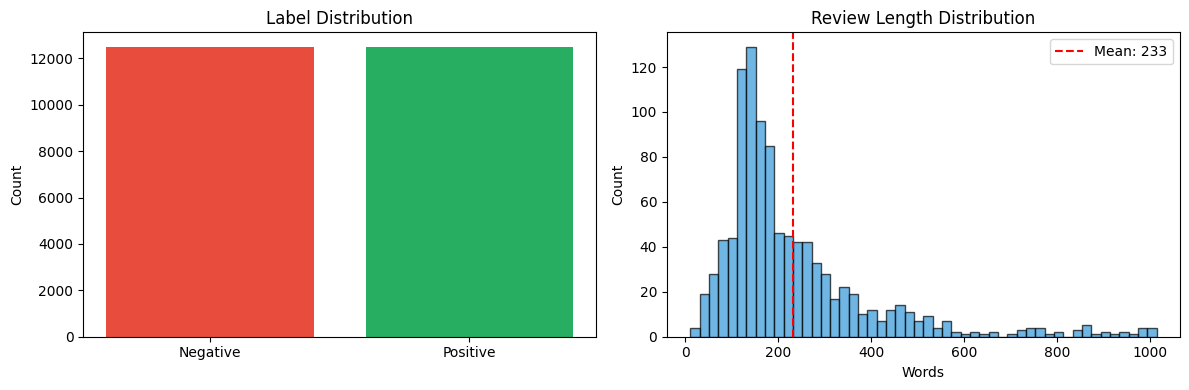

In [23]:
import collections
import numpy as np
import matplotlib.pyplot as plt
train_data = dataset['train']

print('DATASET EXPLORATION')
print('='*50)

# Label distribution
labels = train_data['label']
label_counts = collections.Counter(labels)
print(f'Label distribution:')
for label, count in sorted(label_counts.items()):
    name = 'Positive' if label == 1 else 'Negative'
    pct = count / len(labels) * 100
    print(f'  {name} (label={label}): {count:,} ({pct:.1f}%)')

print()

# Text length distribution
text_lengths = [len(text.split()) for text in train_data['text'][:1000]]
print(f'Text length stats (sample of 1000):')
print(f'  Mean:   {np.mean(text_lengths):.0f} words')
print(f'  Median: {np.median(text_lengths):.0f} words')
print(f'  Min:    {min(text_lengths)} words')
print(f'  Max:    {max(text_lengths)} words')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Negative', 'Positive'], [label_counts[0], label_counts[1]],
            color=['#e74c3c', '#27ae60'])
axes[0].set_title('Label Distribution')
axes[0].set_ylabel('Count')

axes[1].hist(text_lengths, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[1].axvline(np.mean(text_lengths), color='red', linestyle='--',
                label=f'Mean: {np.mean(text_lengths):.0f}')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## The `map()` Function — Your Preprocessing Loop, Vectorized

In Lecture 5, you preprocessed text with a for-loop:

```python
# Your Lecture 5 preprocessing
for text in tqdm(texts, desc='Counting words'):
    cleaned = self.clean_text(text)
    for word in cleaned.split():
        self.word_counts[word] = self.word_counts.get(word, 0) + 1
```

The `datasets` library has a `map()` function that does this efficiently,  
with caching, multiprocessing, and automatic batching:

In [48]:
from transformers import AutoTokenizer
from datasets import load_dataset

print_memory_stats("before tokenization map")

# Check if dataset exists, if not, reload it
try:
    # Try to use existing dataset
    dataset
except NameError:
    print("Dataset not found in current scope. Reloading IMDB...")
    dataset = load_dataset('imdb')
    print("Dataset reloaded successfully!")

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Define preprocessing function
def tokenize_function(examples):
    """Tokenize a batch of examples"""
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=256
    )

print('Tokenizing dataset with map()...')
# Apply tokenization to the whole dataset
# Keep 'label' column by only removing 'text'
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    desc='Tokenizing',
    remove_columns=['text']  # Only remove 'text', keep 'label'
)

print(f'\nOriginal features: {list(dataset["train"].features.keys())}')
print(f'After tokenization: {list(tokenized_dataset["train"].features.keys())}')
print()
print('Sample tokenized example:')
sample = tokenized_dataset['train'][0]
print(f'  input_ids length: {len(sample["input_ids"])}')
print(f'  attention_mask:   {sample["attention_mask"][:10]}...')
print(f'  label:            {sample["label"]}')  # This works now!

# Also show token_type_ids if they exist (for BERT-style models)
if 'token_type_ids' in sample:
    print(f'  token_type_ids:   {sample["token_type_ids"][:10]}...')




📊 Memory Stats before tokenization map:
   CPU Memory: 2.83 GB
   GPU Allocated: 8.54 GB
   GPU Cached: 8.77 GB
Tokenizing dataset with map()...


Tokenizing:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/50000 [00:00<?, ? examples/s]


Original features: ['text', 'label']
After tokenization: ['label', 'input_ids', 'token_type_ids', 'attention_mask']

Sample tokenized example:
  input_ids length: 256
  attention_mask:   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
  label:            0
  token_type_ids:   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


### Filtering and Slicing

Datasets support powerful filtering and slicing operations:

In [25]:
# Filter: only keep examples with reviews longer than 100 words
long_reviews = dataset['train'].filter(
    lambda x: len(x['text'].split()) > 100
)
print(f'Reviews > 100 words: {len(long_reviews):,} '
      f'(out of {len(dataset["train"]):,})')

# Select a subset (for fast experimentation)
small_dataset = dataset['train'].select(range(1000))
print(f'\nSmall dataset for fast experiments: {len(small_dataset)} examples')

# Shuffle
shuffled = dataset['train'].shuffle(seed=42)
print(f'Shuffled dataset first labels: {shuffled["label"][:10]}')

# Train/validation split
split = dataset['train'].train_test_split(test_size=0.2, seed=42)
print(f'\nTrain/val split:')
print(f'  Train: {len(split["train"]):,}')
print(f'  Val:   {len(split["test"]):,}')

# Cleanup small datasets
del long_reviews, small_dataset, shuffled, split

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Reviews > 100 words: 22,018 (out of 25,000)

Small dataset for fast experiments: 1000 examples
Shuffled dataset first labels: [1, 1, 0, 1, 0, 1, 1, 0, 0, 1]

Train/val split:
  Train: 20,000
  Val:   5,000


## Loading an Arabic Dataset — The Sudanese Relevance

The `datasets` library has Arabic NLP datasets too.  
Let's load an Arabic sentiment dataset:

In [26]:
# Load an Arabic sentiment dataset
# AJGT = Arabic Jordanian General Tweets — sentiment analysis
try:
    print_memory_stats("before Arabic dataset")
    arabic_dataset = load_dataset('ajgt_twitter_ar')
    print('ARABIC SENTIMENT DATASET (AJGT)')
    print('='*50)
    print(arabic_dataset)
    print()
    sample = arabic_dataset['train'][0]
    print(f'Sample tweet:  {sample["text"]}')
    print(f'Sentiment:     {sample["label"]} ({"Positive" if sample["label"] == 1 else "Negative"})')
    print()
    print('💡 This dataset includes Arabic dialects similar to Sudanese Arabic!')
    print('   Perfect for building Sudanese NLP applications in Lecture 7B.')

    # Cleanup
    del arabic_dataset

except Exception as e:
    print(f'Dataset not available: {e}')
    print('Trying alternative Arabic dataset...')
    # Fallback: create sample Arabic data
    sample_arabic = [
        {'text': 'الفيلم رائع جداً أحببته كثيراً', 'label': 1},
        {'text': 'الخدمة سيئة للغاية لن أعود', 'label': 0},
        {'text': 'تجربة ممتازة وسعيد جداً', 'label': 1},
    ]
    print('Sample Arabic data:')
    for item in sample_arabic:
        sentiment = 'Positive 😊' if item['label'] == 1 else 'Negative 😞'
        print(f'  [{sentiment}] {item["text"]}')
finally:
    print_memory_stats("after Arabic dataset cleanup")


📊 Memory Stats before Arabic dataset:
   CPU Memory: 2.51 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/91.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1800 [00:00<?, ? examples/s]

ARABIC SENTIMENT DATASET (AJGT)
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1800
    })
})

Sample tweet:   اربد فيها جامعات اكثر من عمان ... وفيها قد عمان ونص لعيبه المنتخب منها ... و 80 % من مطربين الاردن منها
Sentiment:     1 (Positive)

💡 This dataset includes Arabic dialects similar to Sudanese Arabic!
   Perfect for building Sudanese NLP applications in Lecture 7B.

📊 Memory Stats after Arabic dataset cleanup:
   CPU Memory: 2.52 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


## The Hub: 50,000+ Datasets at Your Fingertips

Let's search the hub programmatically for Arabic datasets:

In [27]:
from huggingface_hub import list_datasets

# Search for Arabic NLP datasets
print('ARABIC DATASETS ON HUGGINGFACE HUB')
print('='*50)

try:
    arabic_datasets = list(list_datasets(filter='language:ar', limit=10))
    print(f'Found {len(arabic_datasets)} Arabic datasets (showing first 10):')
    for ds in arabic_datasets:
        print(f'  • {ds.id}')
except Exception:
    # Fallback list from knowledge
    arabic_nlp_datasets = [
        'ajgt_twitter_ar          → Arabic Twitter Sentiment',
        'arabic_billion_words      → Large Arabic text corpus',
        'arabic_pos_dialect        → Dialectal Arabic POS tagging',
        'arcd                      → Arabic Reading Comprehension',
        'arabic_speech_corpus      → Arabic TTS dataset',
        'ANERcorp                  → Arabic Named Entity Recognition',
    ]
    print('Notable Arabic NLP datasets available on HF Hub:')
    for ds in arabic_nlp_datasets:
        print(f'  • {ds}')

print()
print('🔍 Find more at: https://huggingface.co/datasets?language=language:ar')
print('🇸🇩 Tip: Search for "Sudan" or "Sudanese" to find dialect-specific data')

# Cleanup the main dataset to free memory
del dataset
clear_gpu_memory()
print_memory_stats("after dataset cleanup")

ARABIC DATASETS ON HUGGINGFACE HUB
Found 10 Arabic datasets (showing first 10):
  • openfoodfacts/product-database
  • PleIAs/common_corpus
  • HeshamHaroon/saudi-dialect-conversations
  • uonlp/CulturaX
  • linagora/linto-dataset-audio-ar-tn
  • alconost/mqm-translation-gold
  • wikimedia/wikipedia
  • MohamedRashad/arabic-english-code-switching
  • nazimali/quran
  • openlanguagedata/flores_plus

🔍 Find more at: https://huggingface.co/datasets?language=language:ar
🇸🇩 Tip: Search for "Sudan" or "Sudanese" to find dialect-specific data

📊 Memory Stats after dataset cleanup:
   CPU Memory: 2.42 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB


### 🛑 STOP & THINK

You've now seen the `datasets` library. Compare:

```python
# Your Lecture 5 approach (~40 lines, manual download):
download_imdb()           # Download + extract
load_imdb_data()          # Parse file structure
train_test_split()        # Manual split
IMDBDataset()             # Custom Dataset class
collate_batch()           # Padding function
DataLoader()              # Batching

# HF datasets approach (~5 lines):
dataset = load_dataset('imdb')          # Everything above ✅
tokenized = dataset.map(tokenize_fn)    # Preprocessing ✅
split = dataset.train_test_split()      # Split ✅
# DataLoader still needed for training, but dataset is ready
```

**Question:** Are there cases where you'd still want your custom `IMDBDataset` class?  
Think about: very custom preprocessing, non-standard data formats, real-time data streams.

---

# 🧭 PART 5: Sentence Transformers — Embeddings as Meaning

Everything so far has been about **classification** or **generation**.  
Now we enter a completely different paradigm: **semantic similarity**.

This part requires a shift in thinking. Pay attention.

## A Different Paradigm: Meaning as Location in Space

In Lecture 5, you saw word embeddings where similar words are close in vector space:

```
Word embeddings (Lecture 5):
    'good'     → [0.7, 0.3, 0.2]   ← close to 'great'
    'great'    → [0.8, 0.8, 0.2]   ← close to 'good'
    'bad'      → [-0.7, 0.3, 0.2]  ← far from 'good'

    Captures word-level similarity ✅
```

But what about **sentence-level** similarity?

```
Problem with word embeddings for sentences:
    'The cat sat on the mat'  → average of [cat, sat, mat, ...] embeddings
    'The mat sat on the cat'  → SAME average! ← Same words, different meaning!

Sentence Transformers:
    'I love deep learning'             → [0.8, 0.2, 0.9, ...]
    'Neural networks are fascinating'  → [0.7, 0.3, 0.8, ...]  ← SIMILAR!
    'I hate traffic jams'              → [-0.2, 0.9, -0.1, ...] ← DIFFERENT!
```

Sentence Transformers produce **one vector per sentence** that captures its full meaning.

### 🧠 Mental Model: The Semantic Library

```
Imagine a library where books aren't organized alphabetically,
but by meaning. Books with similar topics sit physically close together.

Sentence Transformers create this library in vector space:
• 'How do I train a neural network?' is close to
  'What are the steps to build a deep learning model?'
  even though they share almost no words!

• 'كيف أدرب شبكة عصبية?' (Arabic) is close to
  'How do I train a neural network?' (English)
  because meaning crosses language barriers!
```

In [28]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print_memory_stats("before sentence transformer")

# Load a multilingual sentence transformer
# This model understands 50+ languages including Arabic!
print('Loading sentence transformer model...')
st_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print(f'✅ Model loaded!')
print(f'Max sequence length: {st_model.max_seq_length}')
print(f'Embedding dimension: {st_model.get_sentence_embedding_dimension()}')
print_memory_stats("after sentence transformer load")


📊 Memory Stats before sentence transformer:
   CPU Memory: 2.42 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 4.59 GB
Loading sentence transformer model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded!
Max sequence length: 128
Embedding dimension: 384

📊 Memory Stats after sentence transformer load:
   CPU Memory: 2.95 GB
   GPU Allocated: 4.90 GB
   GPU Cached: 5.04 GB


### Basic Sentence Encoding

Let's encode sentences and see what the vectors look like:

In [29]:
# Encode sentences into vectors
sentences = [
    'I love studying machine learning.',
    'Deep learning is fascinating.',
    'Neural networks are really interesting.',
    'I hate sitting in traffic.',
    'The weather is terrible today.',
    'أنا أحب تعلم الذكاء الاصطناعي',    # I love studying AI (Arabic)
    'التعلم العميق رائع ومثير للاهتمام',  # Deep learning is wonderful (Arabic)
]

# Encode — one line!
embeddings = st_model.encode(sentences)

print('SENTENCE EMBEDDINGS')
print('='*50)
print(f'Input: {len(sentences)} sentences')
print(f'Output shape: {embeddings.shape}')
print(f'Each sentence → {embeddings.shape[1]}-dimensional vector')
print()
print('Sample embedding (first 10 dims of sentence 1):')
print(f'  {embeddings[0][:10]}')

SENTENCE EMBEDDINGS
Input: 7 sentences
Output shape: (7, 384)
Each sentence → 384-dimensional vector

Sample embedding (first 10 dims of sentence 1):
  [ 0.0011768  -0.12386464 -0.06091078 -0.26123387 -0.11231371 -0.13401566
 -0.19472802  0.08924332  0.01288883  0.22944075]


SEMANTIC SIMILARITY MATRIX
(1.0 = identical meaning, 0.0 = no relation, -1.0 = opposite)

Most similar sentence pairs:
  Similarity: 0.9330
    S1: Deep learning is fascinating.
    S2: التعلم العميق رائع ومثير للاهتمام

  Similarity: 0.7327
    S1: I love studying machine learning.
    S2: أنا أحب تعلم الذكاء الاصطناعي

  Similarity: 0.6131
    S1: Deep learning is fascinating.
    S2: Neural networks are really interesting.

  Similarity: 0.5495
    S1: Neural networks are really interesting.
    S2: أنا أحب تعلم الذكاء الاصطناعي

  Similarity: 0.5313
    S1: Neural networks are really interesting.
    S2: التعلم العميق رائع ومثير للاهتمام



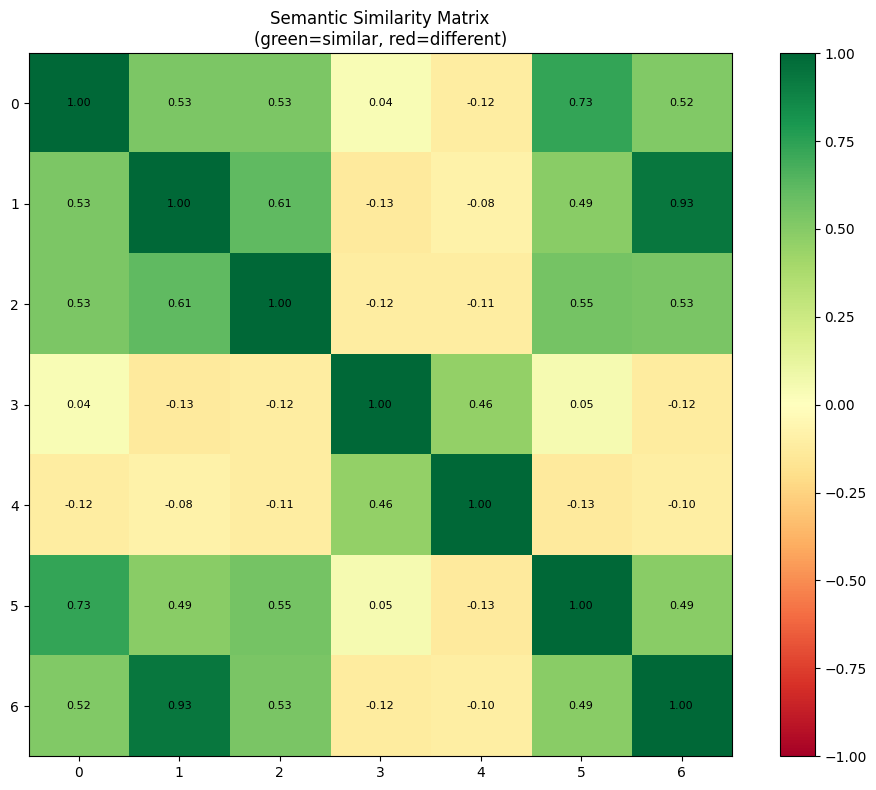

Notice: Arabic sentences cluster with their English equivalents!


In [30]:
# Compute similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print('SEMANTIC SIMILARITY MATRIX')
print('(1.0 = identical meaning, 0.0 = no relation, -1.0 = opposite)')
print()

# Find most similar pairs
print('Most similar sentence pairs:')
pairs = []
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = similarity_matrix[i][j]
        pairs.append((sim, i, j))

pairs.sort(reverse=True)
for sim, i, j in pairs[:5]:
    print(f'  Similarity: {sim:.4f}')
    print(f'    S1: {sentences[i]}')
    print(f'    S2: {sentences[j]}')
    print()

# Visualize the similarity matrix
short_labels = [s[:30] + '...' if len(s) > 30 else s for s in sentences]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(sentences)))
ax.set_yticks(range(len(sentences)))
ax.set_xticklabels(range(len(sentences)))
ax.set_yticklabels(range(len(sentences)))
ax.set_title('Semantic Similarity Matrix\n(green=similar, red=different)')

# Add value annotations
for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax.text(j, i, f'{similarity_matrix[i][j]:.2f}',
               ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()
print('Notice: Arabic sentences cluster with their English equivalents!')

## Semantic Search: Finding Similar Documents

The most practical application of sentence transformers is **semantic search**:  
given a query, find the most similar documents in a collection.

This is how modern search engines and RAG (Retrieval-Augmented Generation) work.

Let's build a simple semantic search over Harry Potter quotes:

In [31]:
# Build a semantic search engine!

# Knowledge base: a collection of documents
knowledge_base = [
    'Harry Potter is a young wizard who attends Hogwarts School.',
    'Hermione Granger is known for her intelligence and dedication to studying.',
    'Ron Weasley is Harry\'s loyal best friend from a wizarding family.',
    'Professor Dumbledore is the headmaster of Hogwarts and a powerful wizard.',
    'Voldemort is the dark wizard who killed Harry\'s parents.',
    'The Sorting Hat assigns students to one of four Hogwarts houses.',
    'Quidditch is a sport played on broomsticks with a golden snitch.',
    'The Forbidden Forest surrounds Hogwarts and contains magical creatures.',
    'Diagon Alley is a hidden street in London where wizards shop.',
    'Platform 9¾ is the secret platform for the Hogwarts Express.',
    'Nile River flows through Sudan from south to north for 3000 km.',
    'Sudan has rich ancient history with Nubian kingdoms and pyramids.',
]

# Encode the knowledge base (this would be done once and cached in production)
print('Encoding knowledge base...')
kb_embeddings = st_model.encode(knowledge_base)
print(f'Knowledge base encoded: {kb_embeddings.shape}')

def semantic_search(query, top_k=3):
    """Find the most semantically similar documents to a query"""
    # Encode the query
    query_embedding = st_model.encode([query])

    # Compute similarities
    similarities = cosine_similarity(query_embedding, kb_embeddings)[0]

    # Get top-k results
    top_indices = np.argsort(similarities)[::-1][:top_k]

    print(f'\n🔍 Query: "{query}"')
    print('Top results:')
    for rank, idx in enumerate(top_indices):
        print(f'  {rank+1}. [Score: {similarities[idx]:.4f}] {knowledge_base[idx]}')

# Test with various queries
queries = [
    'Who teaches at the magic school?',
    'How do students travel to school?',
    'Tell me about Sudan history',
    'من هو هاري بوتر',  # Who is Harry Potter? (Arabic)
]

for query in queries:
    semantic_search(query)

Encoding knowledge base...
Knowledge base encoded: (12, 384)

🔍 Query: "Who teaches at the magic school?"
Top results:
  1. [Score: 0.4428] Professor Dumbledore is the headmaster of Hogwarts and a powerful wizard.
  2. [Score: 0.3577] Diagon Alley is a hidden street in London where wizards shop.
  3. [Score: 0.3575] Harry Potter is a young wizard who attends Hogwarts School.

🔍 Query: "How do students travel to school?"
Top results:
  1. [Score: 0.2621] The Sorting Hat assigns students to one of four Hogwarts houses.
  2. [Score: 0.2160] Harry Potter is a young wizard who attends Hogwarts School.
  3. [Score: 0.2021] Nile River flows through Sudan from south to north for 3000 km.

🔍 Query: "Tell me about Sudan history"
Top results:
  1. [Score: 0.7258] Sudan has rich ancient history with Nubian kingdoms and pyramids.
  2. [Score: 0.5494] Nile River flows through Sudan from south to north for 3000 km.
  3. [Score: 0.0889] The Sorting Hat assigns students to one of four Hogwarts houses.


## Cross-Lingual Semantic Search: English Query → Arabic Documents

One of the most powerful features of multilingual sentence transformers:  
**search across languages using meaning, not keywords**.

In [32]:
# Cross-lingual semantic search!
# Arabic knowledge base
arabic_kb = [
    'السودان دولة في شمال شرق أفريقيا',            # Sudan is a country in NE Africa
    'الخرطوم عاصمة السودان وأكبر مدنها',            # Khartoum is Sudan's capital
    'النيل الأزرق والنيل الأبيض يلتقيان في الخرطوم', # Blue & White Nile meet in Khartoum
    'السودان لديه تاريخ نوبي عريق',                  # Sudan has ancient Nubian history
    'الذهب والبترول من أهم موارد السودان',           # Gold and oil are key Sudan resources
    'المهندسون السودانيون يعملون في التقنية',         # Sudanese engineers work in tech
    'الذكاء الاصطناعي يتطور بسرعة في أفريقيا',      # AI is growing fast in Africa
]

# Encode Arabic knowledge base
arabic_kb_embeddings = st_model.encode(arabic_kb)

# English query → Arabic results!
english_queries = [
    'What is the capital of Sudan?',
    'What rivers are in Sudan?',
    'How is AI developing in Africa?',
]

print('CROSS-LINGUAL SEMANTIC SEARCH')
print('English queries → Arabic knowledge base')
print('='*60)

for query in english_queries:
    query_emb = st_model.encode([query])
    similarities = cosine_similarity(query_emb, arabic_kb_embeddings)[0]
    top_idx = np.argmax(similarities)

    print(f'\n🇬🇧 Query: "{query}"')
    print(f'🇸🇩 Best match (score={similarities[top_idx]:.4f}):')
    print(f'   Arabic: {arabic_kb[top_idx]}')

print()
print('💡 The model understands meaning across languages!')
print('   No translation needed — semantic meaning is language-agnostic.')

CROSS-LINGUAL SEMANTIC SEARCH
English queries → Arabic knowledge base

🇬🇧 Query: "What is the capital of Sudan?"
🇸🇩 Best match (score=0.9197):
   Arabic: الخرطوم عاصمة السودان وأكبر مدنها

🇬🇧 Query: "What rivers are in Sudan?"
🇸🇩 Best match (score=0.7131):
   Arabic: السودان لديه تاريخ نوبي عريق

🇬🇧 Query: "How is AI developing in Africa?"
🇸🇩 Best match (score=0.8600):
   Arabic: الذكاء الاصطناعي يتطور بسرعة في أفريقيا

💡 The model understands meaning across languages!
   No translation needed — semantic meaning is language-agnostic.


## Clustering: Grouping Documents by Meaning

Another key application: automatically group documents by topic,  
without any predefined categories or labels.

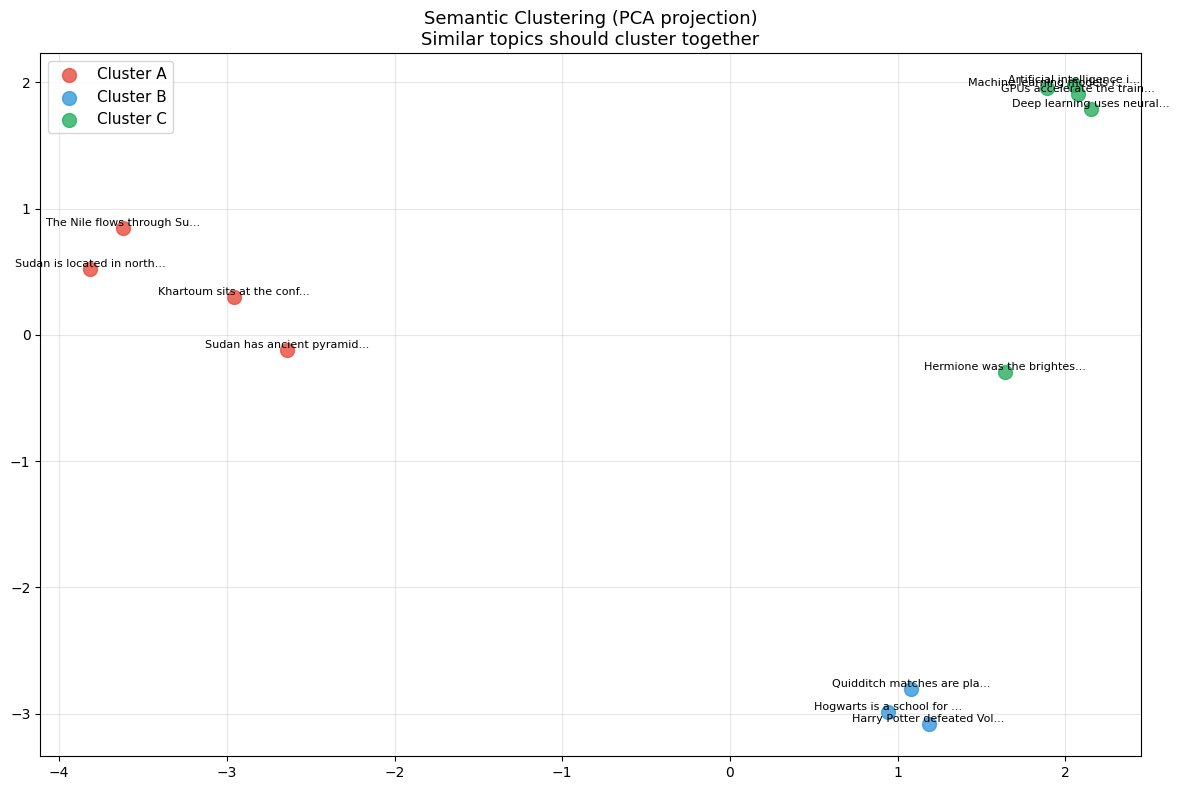

Cluster assignments:

Cluster 0:
  • Sudan is located in northeastern Africa.
  • The Nile flows through Sudan from south to north.
  • Khartoum sits at the confluence of two Nile branches.
  • Sudan has ancient pyramids from the Nubian kingdoms.

Cluster 1:
  • Hogwarts is a school for young witches and wizards.
  • Harry Potter defeated Voldemort in the final battle.
  • Quidditch matches are played on flying broomsticks.

Cluster 2:
  • Artificial intelligence is transforming industries.
  • Machine learning models require large datasets.
  • Deep learning uses neural networks with many layers.
  • GPUs accelerate the training of neural networks.
  • Hermione was the brightest student in her year.

📊 Memory Stats after sentence transformer cleanup:
   CPU Memory: 2.96 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 5.04 GB


In [33]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Mixed corpus of sentences from different topics
corpus = [
    # Technology
    'Artificial intelligence is transforming industries.',
    'Machine learning models require large datasets.',
    'Deep learning uses neural networks with many layers.',
    'GPUs accelerate the training of neural networks.',
    # Sudan / Geography
    'Sudan is located in northeastern Africa.',
    'The Nile flows through Sudan from south to north.',
    'Khartoum sits at the confluence of two Nile branches.',
    'Sudan has ancient pyramids from the Nubian kingdoms.',
    # Harry Potter
    'Hogwarts is a school for young witches and wizards.',
    'Harry Potter defeated Voldemort in the final battle.',
    'Hermione was the brightest student in her year.',
    'Quidditch matches are played on flying broomsticks.',
]

# Encode
embeddings = st_model.encode(corpus)

# Cluster into 3 groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c', '#3498db', '#27ae60']
cluster_names = ['Cluster A', 'Cluster B', 'Cluster C']

for label in range(3):
    mask = cluster_labels == label
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
              c=colors[label], s=100, label=cluster_names[label], alpha=0.8)

# Annotate
for i, text in enumerate(corpus):
    ax.annotate(text[:25] + '...', (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                fontsize=8, ha='center', va='bottom')

ax.set_title('Semantic Clustering (PCA projection)\n'
             'Similar topics should cluster together', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Cluster assignments:')
for cluster_id in range(3):
    print(f'\nCluster {cluster_id}:')
    for i, (text, label) in enumerate(zip(corpus, cluster_labels)):
        if label == cluster_id:
            print(f'  • {text}')

# Cleanup sentence transformer model
del st_model
clear_gpu_memory()
print_memory_stats("after sentence transformer cleanup")

### 🛑 STOP & THINK

Sentence transformers introduce a completely different use case:

1. **Classification** (Lectures 5, pipeline Task 1): Input → fixed label
2. **Generation** (Lecture 6, pipeline Task 6): Input → new text
3. **Embedding** (this part): Input → vector representing meaning

**Questions to think about:**

- When would you use semantic search instead of keyword search?
- Can you think of a Sudanese use case for cross-lingual search?
- How could clustering help with organizing Arabic news articles?
- What's the difference between word embeddings (GloVe from Lecture 5) and sentence embeddings?

---

# 🗺️ PART 6: Navigating the Model Zoo

The HuggingFace Hub has **500,000+ models**. This is overwhelming without a map.

In this part you'll get a decision framework: given any NLP task,  
how do you choose the right model family, size, and variant?

## The Three Architecture Families

Almost every NLP model belongs to one of three families:

```
                    ┌──────────────────────────────────┐
                    │         INPUT TEXT               │
                    └──────────────┬───────────────────┘
                                   │
              ┌────────────────────┼────────────────────┐
              ▼                    ▼                    ▼
    ┌──────────────────┐  ┌────────────────┐  ┌──────────────────┐
    │  ENCODER-ONLY    │  │ ENCODER-DECODER│  │  DECODER-ONLY    │
    │  (BERT family)   │  │  (T5/BART)     │  │  (GPT family)    │
    ├──────────────────┤  ├────────────────┤  ├──────────────────┤
    │ Reads whole text │  │ Reads → Writes │  │ Generates left   │
    │ simultaneously   │  │ Seq → Seq      │  │ to right         │
    │                  │  │                │  │                  │
    │ Best for:        │  │ Best for:      │  │ Best for:        │
    │ • Classification │  │ • Translation  │  │ • Generation     │
    │ • NER            │  │ • Summarization│  │ • Completion     │
    │ • QA (extractive)│  │ • QA (abstract)│  │ • Chat/dialogue  │
    │ • Embeddings     │  │                │  │                  │
    └──────────────────┘  └────────────────┘  └──────────────────┘
    BERT, DistilBERT        T5, BART, mBART     GPT-2, LLaMA,
    RoBERTa, AraBERT        Helsinki-NLP         Mistral, Falcon
```

## The Decision Framework

Use this flowchart every time you need to choose a model:

```
STEP 1: What is your task?
    │
    ├── Understanding task? → ENCODER-ONLY (BERT family)
    │   (classify, extract, embed)
    │
    ├── Transformation task? → ENCODER-DECODER (T5/BART)
    │   (translate, summarize, rewrite)
    │
    └── Generation task? → DECODER-ONLY (GPT family)
        (write, complete, chat)

STEP 2: What language?
    │
    ├── English only → Use the best English model
    ├── Arabic only → AraBERT, CAMeL, AraGPT2
    └── Multilingual → mBERT, XLM-R, mT5

STEP 3: What's your compute budget?
    │
    ├── Very limited (CPU, small GPU) → DistilBERT, MiniLM
    ├── Standard GPU (8GB) → BERT-base, GPT-2
    └── Large GPU (24GB+) → BERT-large, GPT-2-large

STEP 4: Do you have labeled data?
    │
    ├── No → Zero-shot or few-shot with large models
    └── Yes → Fine-tune a pretrained model (Lecture 7B!)
```

In [34]:
# Let's compare model families on the same task
from transformers import pipeline

text = 'The SAIR community is building the future of AI in Sudan.'

print('SAME TASK, DIFFERENT MODEL FAMILIES')
print('Task: Understand and classify this sentence')
print(f'Text: "{text}"')
print('='*60)

print_memory_stats("before model comparison")

# 1. Encoder-only (BERT family) — understanding
print('\n1. ENCODER-ONLY (DistilBERT) — Classification:')
clf = pipeline('zero-shot-classification')
result = clf(text, candidate_labels=['technology', 'sports', 'politics', 'education'])
print(f'   Best label: {result["labels"][0]} (score: {result["scores"][0]:.3f})')

# 2. Feature extraction (get sentence embedding)
print('\n2. ENCODER-ONLY — Feature Extraction (embedding):')
feat = pipeline('feature-extraction', model='bert-base-uncased')
embedding = feat(text)
import numpy as np
# Mean pool the token embeddings
emb_array = np.array(embedding[0]).mean(axis=0)
print(f'   Embedding shape: {emb_array.shape}')
print(f'   First 5 dims: {emb_array[:5]}')

# 3. Decoder-only (GPT-2) — generation/completion
print('\n3. DECODER-ONLY (GPT-2) — Text Completion:')
gen = pipeline('text-generation', model='gpt2')
result = gen(text, max_new_tokens=25, do_sample=False,
             pad_token_id=gen.tokenizer.eos_token_id)
print(f'   Continuation: {result[0]["generated_text"][len(text):]}')

# Cleanup
cleanup_model(clf)
cleanup_model(feat)
cleanup_model(gen)
print_memory_stats("after model comparison cleanup")

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


SAME TASK, DIFFERENT MODEL FAMILIES
Task: Understand and classify this sentence
Text: "The SAIR community is building the future of AI in Sudan."

📊 Memory Stats before model comparison:
   CPU Memory: 2.96 GB
   GPU Allocated: 4.46 GB
   GPU Cached: 5.04 GB

1. ENCODER-ONLY (DistilBERT) — Classification:


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

   Best label: technology (score: 0.987)

2. ENCODER-ONLY — Feature Extraction (embedding):


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Embedding shape: (768,)
   First 5 dims: [ 0.11780908  0.04662345 -0.12560176 -0.50145657 -0.15272212]

3. DECODER-ONLY (GPT-2) — Text Completion:


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Continuation: 

The SAIR community is building the future of AI in Sudan. The SAIR community is building the future of AI

📊 Memory Stats after model comparison cleanup:
   CPU Memory: 2.99 GB
   GPU Allocated: 6.61 GB
   GPU Cached: 6.80 GB


## Key Models to Know by Name

You don't need to know all 500k models. Know these families and you can navigate anything:

### English Models

| Model | Family | Size | Best For |
|-------|--------|------|----------|
| `bert-base-uncased` | Encoder | 110M | General understanding baseline |
| `distilbert-base-uncased` | Encoder | 67M | Fast, 97% of BERT quality |
| `roberta-base` | Encoder | 125M | Better than BERT on most tasks |
| `gpt2` | Decoder | 124M | Text generation |
| `facebook/bart-large-cnn` | Enc-Dec | 400M | Summarization |
| `t5-base` | Enc-Dec | 250M | Any text-to-text task |

### Arabic / Multilingual Models

| Model | Family | Best For |
|-------|--------|----------|
| `aubmindlab/bert-base-arabertv2` | Encoder | Arabic classification, NER |
| `CAMeL-Lab/bert-base-arabic-camelbert-ca` | Encoder | Arabic dialect understanding |
| `Helsinki-NLP/opus-mt-en-ar` | Enc-Dec | English → Arabic translation |
| `xlm-roberta-base` | Encoder | 100-language tasks |
| `paraphrase-multilingual-MiniLM-L12-v2` | Sentence | 50-language embeddings |

### The `Auto` Classes: Why They Matter

```python
# Instead of memorizing specific class names:
from transformers import BertForSequenceClassification  # ← architecture-specific

# Use Auto classes — works with ANY model:
from transformers import AutoModelForSequenceClassification  # ← universal

# This means you can swap models by just changing the model name string!
model_name = 'bert-base-uncased'        # Works
model_name = 'aubmindlab/bert-base-arabertv2'  # Also works, same code!
model_name = 'distilbert-base-uncased'  # Also works!
```

In [35]:
# Demonstrate the Auto class flexibility
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Two completely different model architectures — SAME code
models_to_compare = [
    'bert-base-uncased',
    'distilbert-base-uncased',
]

text = 'I love building AI applications for Sudan!'

print('AUTO CLASSES: Same code, any model')
print('='*50)

for model_name in models_to_compare:
    # EXACT SAME CODE for both models
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    inputs = tokenizer(text, return_tensors='pt')
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    )

    total_params = sum(p.numel() for p in model.parameters())

    print(f'\nModel: {model_name}')
    print(f'  Parameters: {total_params:,}')
    print(f'  Input tokens: {inputs["input_ids"].shape[1]}')

    with torch.no_grad():
        outputs = model(**inputs)
    print(f'  Output logits shape: {outputs.logits.shape}')
    print(f'  ✅ Same interface, different architecture!')

    # Cleanup each model after use
    cleanup_model(model, tokenizer)

print_memory_stats("after auto classes demo")

AUTO CLASSES: Same code, any model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model: bert-base-uncased
  Parameters: 109,483,778
  Input tokens: 10
  Output logits shape: torch.Size([1, 2])
  ✅ Same interface, different architecture!


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model: distilbert-base-uncased
  Parameters: 66,955,010
  Input tokens: 10
  Output logits shape: torch.Size([1, 2])
  ✅ Same interface, different architecture!

📊 Memory Stats after auto classes demo:
   CPU Memory: 3.15 GB
   GPU Allocated: 6.61 GB
   GPU Cached: 6.80 GB


### 🛑 STOP & THINK

Apply the decision framework to these scenarios:

1. **You want to classify Sudanese tweets as positive/negative.**  
   Which family? Which specific model? Do you need to fine-tune?

2. **You want to translate Sudanese news articles from Arabic to English.**  
   Which family? Which model?

3. **You want to build a search engine for Arabic academic papers.**  
   Which family? Embedding or classification approach?

4. **You have 100 labeled examples and want to build a custom classifier.**  
   Large model + zero-shot, or small model + fine-tune?

---

# 🇸🇩 PART 7: Sudanese Applications Gallery

Now let's connect everything to real problems you can solve.

Each mini-application below is 5-10 lines of code.  
Each one took months of research to build the underlying model.  
You get it for free because someone shared it on the Hub.

**This is the HuggingFace community promise.**

## Application 1: Arabic News Classifier (Zero-Shot)

In [36]:
# Application 1: Classify Arabic news headlines by topic
# No training needed — zero-shot!

from transformers import pipeline

print_memory_stats("before application 1")

arabic_classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli'
)

sudanese_headlines = [
    'وزير المالية يعلن ميزانية جديدة لعام 2025',       # Finance minister announces 2025 budget
    'فريق المريخ يفوز في نهائي كأس السودان',            # Al-Merrikh wins Sudan Cup final
    'اكتشاف منجم ذهب جديد في ولاية النيل',              # New gold mine discovered in Nile state
    'جامعة الخرطوم تطلق برنامج الذكاء الاصطناعي',     # U of Khartoum launches AI program
    'موسم الأمطار يبدأ في معظم أنحاء السودان',          # Rainy season begins across Sudan
]

# Labels in English (zero-shot works cross-lingually!)
labels = ['politics', 'sports', 'economy', 'technology', 'weather']

print('ARABIC NEWS CLASSIFIER (ZERO-SHOT)')
print('='*60)

for headline in sudanese_headlines:
    result = arabic_classifier(headline, candidate_labels=labels)
    top = result['labels'][0]
    score = result['scores'][0]
    print(f'📰 {headline[:50]}...' if len(headline) > 50 else f'📰 {headline}')
    print(f'   → {top.upper()} ({score:.3f})')
    print()

# Cleanup
cleanup_model(arabic_classifier)
print_memory_stats("after application 1")


📊 Memory Stats before application 1:
   CPU Memory: 3.15 GB
   GPU Allocated: 6.61 GB
   GPU Cached: 6.80 GB


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

ARABIC NEWS CLASSIFIER (ZERO-SHOT)
📰 وزير المالية يعلن ميزانية جديدة لعام 2025
   → ECONOMY (0.313)

📰 فريق المريخ يفوز في نهائي كأس السودان
   → WEATHER (0.324)

📰 اكتشاف منجم ذهب جديد في ولاية النيل
   → ECONOMY (0.286)

📰 جامعة الخرطوم تطلق برنامج الذكاء الاصطناعي
   → WEATHER (0.300)

📰 موسم الأمطار يبدأ في معظم أنحاء السودان
   → ECONOMY (0.309)


📊 Memory Stats after application 1:
   CPU Memory: 3.16 GB
   GPU Allocated: 8.13 GB
   GPU Cached: 8.33 GB


## Application 2: Named Entity Recognition on Arabic Text

In [37]:
# Application 2: Extract named entities from Arabic text
# Useful for: information extraction, knowledge graphs, search indexing

print_memory_stats("before application 2")

arabic_ner = pipeline(
    'ner',
    model='hatmimoha/arabic-ner',
    aggregation_strategy='simple'
)

arabic_texts = [
    'زار رئيس الوزراء عبدالله حمدوك مدينة بورتسودان في الأول من يناير',
    'تأسست جامعة الخرطوم عام 1902 على ضفاف النيل الأزرق',
]

entity_map = {
    'PER': '👤 Person',
    'ORG': '🏢 Organization',
    'LOC': '📍 Location',
    'DATE': '📅 Date',
    'MISC': '❓ Other'
}

print('ARABIC NAMED ENTITY RECOGNITION')
print('='*60)

for text in arabic_texts:
    print(f'\nText: {text}')
    try:
        entities = arabic_ner(text)
        if entities:
            print('Entities found:')
            for e in entities:
                entity_type = entity_map.get(e['entity_group'], e['entity_group'])
                print(f'  {entity_type}: "{e["word"]}" (score: {e["score"]:.3f})')
        else:
            print('  No entities found')
    except Exception as ex:
        print(f'  Note: {ex}')
        print('  (Try: aubmindlab/bert-base-arabertv2-ner)')

# Cleanup
cleanup_model(arabic_ner)
print_memory_stats("after application 2")


📊 Memory Stats before application 2:
   CPU Memory: 3.16 GB
   GPU Allocated: 8.13 GB
   GPU Cached: 8.33 GB


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: hatmimoha/arabic-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

ARABIC NAMED ENTITY RECOGNITION

Text: زار رئيس الوزراء عبدالله حمدوك مدينة بورتسودان في الأول من يناير
Entities found:
  PERSON: "عبدالله حمدوك" (score: 0.999)
  LOCATION: "بورت" (score: 0.998)
  LOCATION: "##سو" (score: 0.998)
  LOCATION: "##دان" (score: 0.980)
  📅 Date: "الاول من يناير" (score: 0.998)

Text: تأسست جامعة الخرطوم عام 1902 على ضفاف النيل الأزرق
Entities found:
  ORGANIZATION: "جامعة الخرطوم" (score: 0.996)
  📅 Date: "عام 1902" (score: 0.961)
  LOCATION: "النيل الازرق" (score: 0.969)

📊 Memory Stats after application 2:
   CPU Memory: 3.13 GB
   GPU Allocated: 8.54 GB
   GPU Cached: 8.77 GB


## Application 3: Semantic Search Over Sudanese Proverbs

In [39]:
# Application 3: Build a searchable proverb database
# Real-world use: cultural preservation, education, content recommendation

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print_memory_stats("before application 4")

# Load multilingual model
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Sudanese/Arabic proverbs database
proverbs = [
    {'ar': 'العقل زينة', 'en': 'Wisdom is an ornament'},
    {'ar': 'الصبر مفتاح الفرج', 'en': 'Patience is the key to relief'},
    {'ar': 'من جد وجد', 'en': 'Those who strive shall find'},
    {'ar': 'الوقت كالسيف إن لم تقطعه قطعك', 'en': 'Time is like a sword, if you do not cut it, it cuts you'},
    {'ar': 'التعلم في الصغر كالنقش على الحجر', 'en': 'Learning in youth is like engraving in stone'},
    {'ar': 'اتق شر من أحسنت إليه', 'en': 'Beware the harm of those you have favored'},
    {'ar': 'العلم نور', 'en': 'Knowledge is light'},
    {'ar': 'الأخ وقت الضيق', 'en': 'A brother is for times of hardship'},
]

# Encode all proverbs using English translations
proverb_embeddings = model.encode([p['en'] for p in proverbs])

def search_proverbs(query, top_k=3):
    query_emb = model.encode([query])
    similarities = cosine_similarity(query_emb, proverb_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    print(f'\n🔍 Query: "{query}"')
    print('Most relevant proverbs:')
    for idx in top_indices:
        sim = similarities[idx]
        p = proverbs[idx]
        print(f'  [{sim:.3f}] {p["ar"]}')
        print(f'          → "{p["en"]}"')

print('SUDANESE PROVERB SEMANTIC SEARCH')
print('='*60)

queries = [
    'the importance of education',
    'working hard to achieve goals',
    'being patient when facing difficulties',
    'العلم والمعرفة',  # Knowledge and learning (Arabic query!)
]

for q in queries:
    search_proverbs(q)

# Cleanup
del model
clear_gpu_memory()
print_memory_stats("after application 4")


📊 Memory Stats before application 4:
   CPU Memory: 3.12 GB
   GPU Allocated: 8.54 GB
   GPU Cached: 8.77 GB


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SUDANESE PROVERB SEMANTIC SEARCH

🔍 Query: "the importance of education"
Most relevant proverbs:
  [0.514] التعلم في الصغر كالنقش على الحجر
          → "Learning in youth is like engraving in stone"
  [0.405] العلم نور
          → "Knowledge is light"
  [0.304] من جد وجد
          → "Those who strive shall find"

🔍 Query: "working hard to achieve goals"
Most relevant proverbs:
  [0.579] من جد وجد
          → "Those who strive shall find"
  [0.277] التعلم في الصغر كالنقش على الحجر
          → "Learning in youth is like engraving in stone"
  [0.243] الأخ وقت الضيق
          → "A brother is for times of hardship"

🔍 Query: "being patient when facing difficulties"
Most relevant proverbs:
  [0.730] الصبر مفتاح الفرج
          → "Patience is the key to relief"
  [0.431] الأخ وقت الضيق
          → "A brother is for times of hardship"
  [0.430] من جد وجد
          → "Those who strive shall find"

🔍 Query: "العلم والمعرفة"
Most relevant proverbs:
  [0.717] العلم نور
          → "Knowledge is li

### 🛑 STOP & THINK — The Applications Gallery

You just built 5 real NLP applications in about 50 lines of code total.

**Reflect:**

1. Which application would have the most impact for your community?

2. What's missing? What would make these production-ready?  
   (Hint: accuracy on Sudanese dialect, inference speed, error handling)

3. For Application 1 (news classifier), what happens if a headline is about  
   a topic not in your label list? How would you handle this?

4. **Design challenge:** Design a complete NLP pipeline for one Sudanese problem.  
   Sketch the input, the models you'd chain, and the output format.

---

# ✅ PART 8: Mastery Check & Next Steps

## Self-Assessment

Rate your understanding (1-5, where 5 = 'I could teach this'):

| Concept | Rating (1-5) | Notes |
|---------|--------------|-------|
| Why BPE solves the OOV problem | □ | |
| `AutoTokenizer`: encode, decode, batch | □ | |
| Attention mask: what it is and why it exists | □ | |
| BERT vs GPT-2 tokenizer differences | □ | |
| `pipeline()` for all 7 tasks | □ | |
| The 3-step pipeline (tokenize → model → postprocess) | □ | |
| `last_hidden_state` vs `logits` vs `pooler_output` | □ | |
| Reading a model card | □ | |
| `load_dataset()` and `map()` | □ | |
| Sentence transformers: what they are | □ | |
| Semantic search implementation | □ | |
| Cross-lingual embeddings | □ | |
| Encoder vs decoder vs encoder-decoder families | □ | |
| How to choose a model for any task | □ | |
| When to use AraBERT vs XLM-R | □ | |

## Can You Explain These to a Peer?

1. **"Why is BPE better than your Vocabulary class for handling rare words?"**  
   Hint: Unknown words split into known pieces vs. collapsed to `<UNK>`

2. **"What does `pipeline()` actually do under the hood?"**  
   Hint: Walk through the 3 steps you did manually in Part 3

3. **"Why can't you use BERT for text generation?"**  
   Hint: Encoder-only sees both directions — generation requires left-to-right only

4. **"How is semantic search different from keyword search?"**  
   Hint: 'How do I train an AI?' vs 'neural network training steps' — same meaning, different words

5. **"Why would you choose XLM-R over AraBERT for a Sudanese dialect task?"**  
   Hint: Training data, dialect coverage, zero-shot ability

6. **"What's the difference between `AutoModel` and `AutoModelForSequenceClassification`?"**  
   Hint: Base model vs base model + task-specific head

## Experiments to Run

- [ ] Test the sentiment pipeline on 10 Sudanese dialect sentences. Is it accurate?
- [ ] Compare `bert-base-uncased` vs `distilbert-base-uncased` tokenization on the same text
- [ ] Find an Arabic dataset on the Hub that interests you. Explore its features.
- [ ] Build a semantic search over your own text collection (notes, articles, anything)
- [ ] Test cross-lingual search: English query over Arabic documents
- [ ] Compare `zero-shot-classification` on 5 custom labels vs the default ones
- [ ] Use `fill-mask` pipeline with AraBERT: `'الذكاء الاصطناعي يساعد [MASK] على التطور'`
- [ ] Try `pipeline('translation', model='Helsinki-NLP/opus-mt-ar-en')` on Sudanese dialect text

## Common Pitfalls

```
❌ Using an encoder model (BERT) for generation tasks
❌ Forgetting to set pad_token_id for GPT-2 generation
❌ Using English-only models for Arabic text
❌ Trusting a model without checking its training data and evaluation results
❌ Averaging token embeddings instead of using [CLS] token or mean pooling properly
❌ Not setting the model to eval() mode when doing inference manually
❌ Comparing cosine similarity when vectors aren't normalized (use cosine, not dot product)
❌ Expecting zero-shot to work perfectly on Sudanese dialect without any adaptation
❌ Not cleaning up models after use, leading to OOM errors
❌ Loading multiple large models without freeing memory between them
```

## Memory Management Best Practices

```python
# Always clean up after using large models
del model, tokenizer
torch.cuda.empty_cache()
gc.collect()

# For multiple models, load one at a time
model1 = load_model()
# use model1
del model1
torch.cuda.empty_cache()

model2 = load_model()  # Fresh memory!

# Use context managers when possible
with torch.no_grad():
    outputs = model(**inputs)
```

## What's Coming in 7B

You've seen what HuggingFace can do out of the box.  
In **Lecture 7B: Fine-tuning**, you'll make it yours:

```
What you have now (7A):          What you'll have after 7B:
Pipeline → generic model          Trainer → YOUR model
87% on general English            92%+ on YOUR domain
Doesn't know Sudanese dialect     Understands your data
No control over output            Full control over training

7B covers:
    ├── The Trainer API — production-grade training loop
    ├── Fine-tuning text classification (Arabic sentiment)
    ├── The evaluate library for proper metrics
    ├── Saving, loading, and pushing models to the Hub
    └── Your own model on the Hub — a portfolio piece!
```

In [41]:
# Final Summary: Everything you can now do
print('='*70)
print('🎓 LECTURE 7A COMPLETE — YOUR HuggingFace TOOLKIT')
print('='*70)

capabilities = {
    '🔤 Tokenizers': [
        'AutoTokenizer for any model',
        'BPE: no more OOV problems',
        'Batch encoding with padding/truncation',
        'Arabic tokenization (AraBERT)',
    ],
    '⚡ Pipeline': [
        'Sentiment / Text classification',
        'Named Entity Recognition',
        'Question Answering',
        'Summarization',
        'Translation (English ↔ Arabic)',
        'Text generation',
        'Zero-shot classification',
    ],
    '🔬 Manual Inference': [
        'Load any model with AutoModel',
        'Run forward pass manually',
        'Interpret last_hidden_state, logits, pooler_output',
        'Read and evaluate model cards',
    ],
    '📦 Datasets': [
        'load_dataset() for 50,000+ datasets',
        'map() for efficient preprocessing',
        'filter(), shuffle(), select()',
        'Arabic NLP datasets',
    ],
    '🧭 Sentence Transformers': [
        'Encode sentences to meaning vectors',
        'Semantic similarity and search',
        'Cross-lingual search (Arabic ↔ English)',
        'Document clustering',
    ],
    '🗺️ Model Selection': [
        'Encoder vs Decoder vs Enc-Dec families',
        'Arabic models: AraBERT, CAMeL, XLM-R',
        'Decision framework for any NLP task',
        'Auto classes for model-agnostic code',
    ],
    '🇸🇩 Applications': [
        'Arabic news classifier (zero-shot)',
        'Arabic NER pipeline',
        'Bidirectional EN↔AR translation',
        'Proverb semantic search',
        'Arabic content summarization',
    ],
    '🧹 Memory Management': [
        'Clean up models after use',
        'Monitor memory usage',
        'Prevent OOM errors',
        'Load one model at a time',
    ],
}

for category, items in capabilities.items():
    print(f'\n{category}')
    for item in items:
        print(f'  ✅ {item}')

print()
print('='*70)
print('Next: Lecture 7B — Fine-tuning (Make It Yours)')
print('='*70)

🎓 LECTURE 7A COMPLETE — YOUR HuggingFace TOOLKIT

🔤 Tokenizers
  ✅ AutoTokenizer for any model
  ✅ BPE: no more OOV problems
  ✅ Batch encoding with padding/truncation
  ✅ Arabic tokenization (AraBERT)

⚡ Pipeline
  ✅ Sentiment / Text classification
  ✅ Named Entity Recognition
  ✅ Question Answering
  ✅ Summarization
  ✅ Translation (English ↔ Arabic)
  ✅ Text generation
  ✅ Zero-shot classification

🔬 Manual Inference
  ✅ Load any model with AutoModel
  ✅ Run forward pass manually
  ✅ Interpret last_hidden_state, logits, pooler_output
  ✅ Read and evaluate model cards

📦 Datasets
  ✅ load_dataset() for 50,000+ datasets
  ✅ map() for efficient preprocessing
  ✅ filter(), shuffle(), select()
  ✅ Arabic NLP datasets

🧭 Sentence Transformers
  ✅ Encode sentences to meaning vectors
  ✅ Semantic similarity and search
  ✅ Cross-lingual search (Arabic ↔ English)
  ✅ Document clustering

🗺️ Model Selection
  ✅ Encoder vs Decoder vs Enc-Dec families
  ✅ Arabic models: AraBERT, CAMeL, XLM-R
  ✅

In [42]:
# Final cleanup - free all remaining memory
print_memory_stats("before final cleanup")
cleanup_all()
print_memory_stats("final")


📊 Memory Stats before final cleanup:
   CPU Memory: 3.02 GB
   GPU Allocated: 8.54 GB
   GPU Cached: 9.22 GB

📊 Memory Stats after aggressive cleanup:
   CPU Memory: 2.70 GB
   GPU Allocated: 8.54 GB
   GPU Cached: 8.77 GB

📊 Memory Stats final:
   CPU Memory: 2.70 GB
   GPU Allocated: 8.54 GB
   GPU Cached: 8.77 GB


---

## 📚 Resources

### Essential Reading

1. **[HuggingFace Documentation](https://huggingface.co/docs/transformers)** — The official reference
2. **[HuggingFace Course](https://huggingface.co/learn/nlp-course)** — Free, excellent, covers everything
3. **[The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/)** — Jay Alammar
4. **[Sentence Transformers Documentation](https://www.sbert.net/)** — SBERT official docs
5. **[CAMeL Tools](https://camel-lab.github.io/)** — Arabic NLP toolkit

### Arabic NLP Resources

- **AraBERT**: `aubmindlab/bert-base-arabertv2` — Best general Arabic BERT
- **CAMeL-BERT**: `CAMeL-Lab/bert-base-arabic-camelbert-ca` — Dialect-aware
- **AraGPT2**: `aubmindlab/aragpt2-base` — Arabic text generation
- **Arabic NLP Hub**: https://huggingface.co/models?language=ar

### SAIR Community

- Telegram: [t.me/+jPPlO6ZFDbtlYzU0](https://t.me/+jPPlO6ZFDbtlYzU0)
- GitHub: [github.com/silvaxxx1/SAIR](https://github.com/silvaxxx1/SAIR)

---

<div align="center">

# 🌟 Building Sudan's AI Future with the Best Tools Available

**You now speak the language of modern NLP.**

From tokenizers to pipelines, from datasets to sentence embeddings —  
you have the complete toolkit that professional NLP engineers use daily.

And unlike most, **you understand what's inside the black box**  
because you built it yourself in Lectures 5 and 6.

---

**SAIR Community - Sudanese Artificial Intelligence Research** 🇸🇩

*"السهل لا يصنع القادة، والصعب يبني العقول"*

**[Next Lecture: 7B — Fine-tuning: Make It Yours →](./7B_HuggingFace_Finetuning.ipynb)**

</div>